# Temperature Differential Impact on Science Image Quality

Investigates how thermal gradients inside the dome — and between the dome interior and outside
air — correlate with PSF degradation in LSSTCam science exposures.

**Data sources**

| Source | Topic / Table | Index | Key fields |
|---|---|---|---|
| EFD — dome air temperature | `lsst.sal.ESS.temperature` | 111, 112, 113 | `temperatureItem*` |
| EFD — turbulence (sonic anemometer) | `lsst.sal.ESS.airTurbulence` | 110 | `speedMagnitude`, `sonicTemperatureStdDev` |
| EFD — outside air & wind | `lsst.sal.ESS.temperature` / `airFlow` | 301 | `temperatureItem*`, `speed`, `direction` |
| ConsDB — PSF metrics | `cdb_lsstcam.visit1_quicklook` | — | `psf_sigma_median`, `donut_blur_fwhm`, `aos_fwhm` |

**Date range:** mid-April 2025 → today (May 2026)


## Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline


## Configuration

In [2]:

# ── Time range ────────────────────────────────────────────────────────────────
t_start = Time("2025-04-15T00:00:00", scale="utc")
t_end   = Time("2026-05-12T23:59:59", scale="utc")
day_obs_start = 20250415
day_obs_end   = 20260512

print(f"Time window : {t_start.iso}  →  {t_end.iso}")
print(f"day_obs     : {day_obs_start}  →  {day_obs_end}")

# ── EFD ───────────────────────────────────────────────────────────────────────
EFD_ALIAS = "usdf_efd"

TEMP_TOPIC      = "lsst.sal.ESS.temperature"
TURB_TOPIC      = "lsst.sal.ESS.airTurbulence"
FLOW_TOPIC      = "lsst.sal.ESS.airFlow"

# Inside dome temperature sensors (salIndex → human label)
INSIDE_TEMP_SENSORS = {
    111: "Camera inlet",
    112: "M2 vicinity",
    113: "M1M3 vicinity",
}

# Mirror glass temperature sensor arrays (4 units × 16 channels each = 64 sensors)
GLASS_TEMP_SENSORS = {
    114: "Glass array 114",
    115: "Glass array 115",
    116: "Glass array 116",
    117: "Glass array 117",
}

# Turbulence (sonic anemometer on TMA platform)
TURB_INDEX = 110
TURB_LABEL = "TMA Platform"

# Outside weather station
WX_INDEX = 301
WX_LABEL = "Cal-Hill weather station"

# Spurious turbulence speed clip (m/s)
TURB_SPEED_MAX = 15.0

# ── DIMM seeing monitor ────────────────────────────────────────────────────────
# Rubin DIMM reports free-atmosphere seeing already corrected to zenith / 500 nm.
# fwhm field is in arcseconds.
DIMM_TOPIC = "lsst.sal.DIMM.logevent_dimmMeasurement"
DIMM_INDEX = 1          # salIndex — update if different in your EFD

# ── ConsDB / PostgreSQL ───────────────────────────────────────────────────────
PGPASS_FILE  = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST  = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB    = "exposurelog"
CONSDB_USER  = "usdf"
SCHEMA       = "cdb_lsstcam"

# ── Quality cuts ──────────────────────────────────────────────────────────────
AOS_FWHM_MAX = 0.75   # arcsec — exclude frames with poor AOS correction
ZP_SCALE_MIN = 0.75   # exclude low-throughput frames
BAND_EXCLUDE = ["y"]  # y-band excluded (large PSF corrections)

# ── Pixel scale ───────────────────────────────────────────────────────────────
PIXEL_SCALE = 0.2     # arcsec per pixel (LSSTCam)
# PSF FWHM (arcsec) = psf_sigma_median (pixels) × 2.355 × PIXEL_SCALE

# ── Band effective wavelengths (nm) for chromatic seeing correction ────────────
# Used to normalise PSF / donut / AOS FWHM to a common reference of 500 nm.
# Values are approximate pivot wavelengths for the Rubin passbands.
# Atmospheric seeing scales as λ^(-1/5):  θ_500 = θ_obs × (λ_eff / 500)^(1/5)
BAND_EFF_WAVELENGTH_NM = {
    "u":  370,
    "g":  480,
    "r":  620,
    "i":  750,
    "z":  870,
    "y":  970,
}

# ── Elevation-dependent sensor height correction ───────────────────────────────
SENSOR_HEIGHT_COEFS = {
    111: dict(sin_coef= 1.76, cos_coef= 3.60),   # Camera inlet
    112: dict(sin_coef= 5.97, cos_coef=-1.00),   # M2 vicinity
    113: dict(sin_coef=-1.38, cos_coef= 4.08),   # M1M3 vicinity
}

DOME_LAPSE_RATE = 0.0098   # °C per metre

# ── Parquet cache ────────────────────────────────────────────────────────────
from pathlib import Path as _Path
CACHE_FILE = _Path("../data/thermal_psf_joined.parquet")
FORCE_REFETCH = False         # Set True to bypass cache and re-fetch all data
INCREMENTAL_REFETCH = False   # Set True to fetch only new data since last cache date

Time window : 2025-04-15 00:00:00.000  →  2026-05-12 23:59:59.000
day_obs     : 20250415  →  20260512


## Connect to EFD and ConsDB

In [3]:
efd_client = EfdClient(EFD_ALIAS)
print("Connected to EFD")


Connected to EFD


In [4]:
def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) < 5:
                continue
            h, db, u_ = parts[0], parts[2], parts[3]
            pwd = ":".join(parts[4:])
            if h == host and db == database and u_ == user:
                return pwd
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

print("Connected to ConsDB")


Connected to ConsDB


In [5]:
# ── Load df_work from cache if available ────────────────────────────────────
_cached_df_work = None  # populated only in incremental mode
_incremental = False

if CACHE_FILE.exists() and not FORCE_REFETCH:
    if INCREMENTAL_REFETCH:
        # Load existing cache, then restrict the fetch window to new data only
        _cached_df_work = pd.read_parquet(CACHE_FILE)
        if not isinstance(_cached_df_work.index, pd.DatetimeIndex):
            if "index" in _cached_df_work.columns:
                _cached_df_work = _cached_df_work.set_index("index")
            _cached_df_work.index = pd.to_datetime(_cached_df_work.index, utc=True)
        _cached_df_work.index.name = "midpt_utc"
        _cache_end = _cached_df_work.index.max()
        # Advance t_start / day_obs_start to the day after the last cached entry
        _next_day = (_cache_end + pd.Timedelta("1day")).normalize().tz_convert(None)
        if _next_day >= pd.Timestamp(t_end.datetime):
            # Cache is already up-to-date
            df_work = _cached_df_work
            _from_cache = True
            _cached_df_work = None
            print(f"Cache already up-to-date through {_cache_end.date()} (t_end = {t_end.iso[:10]}).")
        else:
            t_start = Time(_next_day.isoformat(), scale="utc")
            day_obs_start = int(_next_day.strftime("%Y%m%d"))
            _from_cache = False
            _incremental = True
            print(f"Incremental refetch: cache has {len(_cached_df_work):,} rows through {_cache_end.date()}")
            print(f"  Fetching new data: {t_start.iso[:10]}  →  {t_end.iso[:10]}")
    else:
        # Load full cache and skip all fetches
        df_work = pd.read_parquet(CACHE_FILE)
        if not isinstance(df_work.index, pd.DatetimeIndex):
            if "index" in df_work.columns:
                df_work = df_work.set_index("index")
            df_work.index = pd.to_datetime(df_work.index, utc=True)
        df_work.index.name = "midpt_utc"
        _from_cache = True
        print(f"Loaded df_work from cache: {df_work.shape}")
        print(f"  Date range: {df_work.index.min().date()} → {df_work.index.max().date()}")
        print("  Skipping EFD/ConsDB fetches — set FORCE_REFETCH=True or INCREMENTAL_REFETCH=True.")
else:
    _from_cache = False
    if not CACHE_FILE.exists():
        print("No cache found — will fetch from EFD + ConsDB.")
    else:
        print("FORCE_REFETCH=True — re-fetching all data.")

Loaded df_work from cache: (74026, 70)
  Date range: 2025-04-16 → 2026-05-13
  Skipping EFD/ConsDB fetches — set FORCE_REFETCH=True or INCREMENTAL_REFETCH=True.


## 1. Fetch Science Exposures + PSF Metrics from ConsDB

In [6]:
if not _from_cache:
    df_exp = consdb_query(f"""
        SELECT
            e.exposure_id,
            e.day_obs,
            e.seq_num,
            e.obs_start,
            e.obs_start_mjd,
            e.exp_time,
            e.airmass,
            e.s_ra,
            e.s_dec,
            e.azimuth,
            e.altitude,
            e.band,
            e.physical_filter,
            e.target_name,
            e.img_type,
            e.wind_speed,
            e.wind_dir,
            e.air_temp      AS consdb_air_temp,
            e.humidity      AS consdb_humidity,
            e.dimm_seeing,
            -- PSF and image-quality metrics from visit1_quicklook
            q.psf_sigma_median,
            q.seeing_zenith_500nm_median,
            q.donut_blur_fwhm,
            q.aos_fwhm,
            q.eff_time_median,
            q.eff_time_zero_point_scale_median,
            q.sky_bg_median,
            q.zero_point_median,
            -- Zernike terms (focus / astigmatism / coma)
            q.z4, q.z5, q.z6, q.z7, q.z8, q.z9, q.z10, q.z11,
            -- Mount jitter from exposure_quicklook
            m.mount_jitter_rms,
            m.mount_motion_image_degradation
        FROM {SCHEMA}.exposure e
        LEFT JOIN {SCHEMA}.visit1_quicklook  q
               ON q.day_obs = e.day_obs AND q.seq_num = e.seq_num
        LEFT JOIN {SCHEMA}.exposure_quicklook m
               ON m.day_obs = e.day_obs AND m.seq_num = e.seq_num
        WHERE e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
          AND e.img_type = 'science'
        ORDER BY e.obs_start_mjd
    """)

    df_exp["obs_start_utc"] = pd.to_datetime(df_exp["obs_start"], utc=True)
    df_exp = df_exp.sort_values("obs_start_utc").set_index("obs_start_utc")

    print(f"Science exposures  : {len(df_exp)}")
    print(f"Date range         : {df_exp.index.min()} → {df_exp.index.max()}")
    print(f"With psf_sigma     : {df_exp['psf_sigma_median'].notna().sum()}")
    print(f"With donut_blur    : {df_exp['donut_blur_fwhm'].notna().sum()}")
    print(f"With aos_fwhm      : {df_exp['aos_fwhm'].notna().sum()}")
    print(f"\nBand distribution:")
    display(df_exp["band"].value_counts())
    df_exp.head()
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


## 2. Fetch EFD Telemetry (Chunked)

The 13-month window is too large for a single EFD query.
`fetch_chunked` splits the window into daily slices.


In [7]:
async def fetch_chunked(client, topic, fields, t0, t1, index=None,
                        chunk=TimeDelta(1 * u.day)):
    """
    Fetch an EFD time-series topic in daily slices to stay under the row limit.
    Returns a single concatenated, sorted DataFrame (empty if nothing found).
    """
    chunks = []
    t_lo = t0
    kwargs = {} if index is None else {"index": index}
    while t_lo < t1:
        t_hi = min(t_lo + chunk, t1)
        try:
            df = await client.select_time_series(
                topic, fields=fields, start=t_lo, end=t_hi, **kwargs
            )
            if not df.empty:
                chunks.append(df)
        except Exception as e:
            print(f"    chunk {t_lo.iso[:10]} error: {e}")
        t_lo = t_hi
    if not chunks:
        return pd.DataFrame()
    return pd.concat(chunks).sort_index()


def mean_temp_cols(df):
    """Mean across all temperatureItem* columns in a DataFrame."""
    cols = [c for c in df.columns if "temperature" in c.lower()]
    if not cols:
        return pd.Series(dtype=float)
    return df[cols].mean(axis=1)


print("Helpers defined.")


Helpers defined.


### 2a. Inside dome temperature sensors — ESS:111, 112, 113 (combined OR query)

In [8]:
import asyncio

async def fetch_temp_multi_index(client, topic, t0, t1, indices,
                                  chunk=TimeDelta(1 * u.day)):
    """
    Fetch temperature data for multiple salIndex values in parallel
    (all indices are queried simultaneously within each daily chunk via
    asyncio.gather, so the wall-clock time ≈ cost of fetching one sensor).

    Returns dict {salIndex (int): DataFrame}.
    """
    result = {idx: [] for idx in indices}

    t_lo = t0
    while t_lo < t1:
        t_hi = min(t_lo + chunk, t1)

        # Fire all sensor queries simultaneously for this chunk
        tasks = [
            client.select_time_series(topic, fields="*", start=t_lo, end=t_hi, index=idx)
            for idx in indices
        ]
        frames = await asyncio.gather(*tasks, return_exceptions=True)

        for idx, frame in zip(indices, frames):
            if isinstance(frame, Exception):
                print(f"    chunk {t_lo.iso[:10]} ESS:{idx} error: {frame}")
            elif not frame.empty:
                result[idx].append(frame)

        t_lo = t_hi

    return {
        idx: (pd.concat(chunks).sort_index() if chunks else pd.DataFrame())
        for idx, chunks in result.items()
    }
if not _from_cache:
    print("Fetching inside dome temperatures — ESS:111, 112, 113 (parallel per chunk) …")
    inside_temp_raw = await fetch_temp_multi_index(
        efd_client, TEMP_TOPIC,
        t0=t_start, t1=t_end,
        indices=list(INSIDE_TEMP_SENSORS.keys()),
    )

    for idx, label in INSIDE_TEMP_SENSORS.items():
        df = inside_temp_raw.get(idx, pd.DataFrame())
        if df.empty:
            print(f"  ESS:{idx} ({label}): no data")
        else:
            tcols = [c for c in df.columns if "temperature" in c.lower()]
            print(f"  ESS:{idx} ({label}): {len(df):,} rows | "
                  f"temp cols: {tcols[:4]}" + (" …" if len(tcols) > 4 else ""))
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


### 2b. Turbulence sensor — ESS:110 (TMA Platform)

In [9]:
import re as _re_dbg

t_test = t_start
t_test_end = t_start + TimeDelta(1 * u.day)

# 1) Check the raw query string
base_q = efd_client.build_time_range_query(TEMP_TOPIC, fields="*", start=t_test, end=t_test_end, index=111)
print("=== base_query ===")
print(base_q)
print()

# 2) Check regex match
m_str = _re_dbg.search(r'"salIndex"\s*=\s*\'[^\']*\'', base_q)  # string-quoted
m_int = _re_dbg.search(r'"salIndex"\s*=\s*\d+', base_q)          # integer
print(f"Regex match (quoted '111'): {m_str}")
print(f"Regex match (integer 111): {m_int}")
print()

# 3) Short fetch for 112 and 113 individually to see if they have data
df_112 = await efd_client.select_time_series(TEMP_TOPIC, fields="*", start=t_test, end=t_test_end, index=112)
df_113 = await efd_client.select_time_series(TEMP_TOPIC, fields="*", start=t_test, end=t_test_end, index=113)
print(f"ESS:112 one-day rows: {len(df_112):,}  columns: {list(df_112.columns)[:6]}")
print(f"ESS:113 one-day rows: {len(df_113):,}  columns: {list(df_113.columns)[:6]}")
print()

# 4) Check salIndex column in inside_temp_raw[111] (already fetched)
df111 = inside_temp_raw.get(111, None)
if df111 is not None and not df111.empty:
    print(f"inside_temp_raw[111] shape: {df111.shape}")
    print(f"columns with 'sal' in name: {[c for c in df111.columns if 'sal' in c.lower() or 'index' in c.lower()]}")
    print(f"first 3 columns: {list(df111.columns[:3])}")


=== base_query ===
SELECT * FROM "efd"."autogen"."lsst.sal.ESS.temperature" WHERE time >= '2025-04-15T00:00:00.000Z' AND time <= '2025-04-16T00:00:00.000Z' AND salIndex = 111

Regex match (quoted '111'): None
Regex match (integer 111): None



ESS:112 one-day rows: 63,664  columns: ['location', 'numChannels', 'private_efdStamp', 'private_identity', 'private_kafkaStamp', 'private_origin']
ESS:113 one-day rows: 60,394  columns: ['location', 'numChannels', 'private_efdStamp', 'private_identity', 'private_kafkaStamp', 'private_origin']



NameError: name 'inside_temp_raw' is not defined

In [10]:
if not _from_cache:
    print(f"Fetching ESS:{TURB_INDEX} ({TURB_LABEL}) airTurbulence …")
    df_turb_raw = await fetch_chunked(
        efd_client, TURB_TOPIC,
        fields=["speedMagnitude", "sonicTemperatureStdDev"],
        t0=t_start, t1=t_end, index=TURB_INDEX,
    )

    if df_turb_raw.empty:
        print("  → no turbulence data found")
    else:
        # Clip spurious high-speed artefacts
        n_before = len(df_turb_raw)
        df_turb_raw = df_turb_raw[df_turb_raw["speedMagnitude"] < TURB_SPEED_MAX]
        print(f"  → {len(df_turb_raw):,} rows ({n_before - len(df_turb_raw):,} clipped >= {TURB_SPEED_MAX} m/s)")
        print(f"  speed magnitude: {df_turb_raw['speedMagnitude'].describe()}")
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


### 2c. Weather station — ESS:301 (outside air temperature + wind)

In [11]:
if not _from_cache:
    print(f"Fetching ESS:{WX_INDEX} ({WX_LABEL}) — outside temperature …")
    df_wx_temp_raw = await fetch_chunked(
        efd_client, TEMP_TOPIC, fields="*",
        t0=t_start, t1=t_end, index=WX_INDEX,
    )
    print(f"  → {len(df_wx_temp_raw):,} rows")

    print(f"Fetching ESS:{WX_INDEX} ({WX_LABEL}) — airFlow (wind) …")
    df_wx_wind_raw = await fetch_chunked(
        efd_client, FLOW_TOPIC,
        fields=["speed", "direction"],
        t0=t_start, t1=t_end, index=WX_INDEX,
    )
    print(f"  → {len(df_wx_wind_raw):,} rows")
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


### 2d. Mirror glass temperature sensors — ESS:114–117 (4 units × 16 channels)

Each unit reports 16 individual `temperatureItem*` channels.  The per-unit mean
(across 16 channels) is computed first, then the **median** of the 4 unit means
is used as the bulk glass temperature.  The **std** of the 4 unit means captures
inter-unit gradients across the mirror surface.


In [12]:
if not _from_cache:
    print("Fetching mirror glass temperatures — ESS:114, 115, 116, 117 (parallel per chunk) …")
    glass_temp_raw = await fetch_temp_multi_index(
        efd_client, TEMP_TOPIC,
        t0=t_start, t1=t_end,
        indices=list(GLASS_TEMP_SENSORS.keys()),
    )

    for idx, label in GLASS_TEMP_SENSORS.items():
        df = glass_temp_raw.get(idx, pd.DataFrame())
        if df.empty:
            print(f"  ESS:{idx} ({label}): no data")
        else:
            tcols = [c for c in df.columns if "temperature" in c.lower()]
            print(f"  ESS:{idx} ({label}): {len(df):,} rows | {len(tcols)} temp channels")
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


### 2e. DIMM seeing — free-atmosphere seeing monitor

`DIMM_TOPIC` = `lsst.sal.DIMM.logevent_dimmMeasurement`.  The DIMM already
reports seeing corrected to zenith / 500 nm (`fwhm` field, arcsec).
Update `DIMM_TOPIC` / `DIMM_INDEX` in the config cell if needed.

In [13]:
if not _from_cache:

    print(f"Fetching DIMM seeing — {DIMM_TOPIC} (index {DIMM_INDEX}) …")
    try:
        df_dimm_raw = await fetch_chunked(
            efd_client, DIMM_TOPIC, fields="*",
            t0=t_start, t1=t_end, index=DIMM_INDEX,
        )
        if df_dimm_raw.empty:
            # Some topics don't use salIndex — retry without it
            df_dimm_raw = await fetch_chunked(
                efd_client, DIMM_TOPIC, fields="*",
                t0=t_start, t1=t_end,
            )
        if df_dimm_raw.empty:
            print("  → no DIMM data found; DIMM comparison will be skipped")
        else:
            print(f"  → {len(df_dimm_raw):,} DIMM measurements")
            print(f"  columns: {list(df_dimm_raw.columns)}")
            # Identify the FWHM column (may be called 'fwhm', 'seeing', etc.)
            fwhm_candidates = [c for c in df_dimm_raw.columns
                               if "fwhm" in c.lower() or "seeing" in c.lower()]
            if fwhm_candidates:
                print(f"  FWHM/seeing columns: {fwhm_candidates}")
                print(df_dimm_raw[fwhm_candidates[0]].describe())
            else:
                print("  WARNING: no fwhm/seeing column found — check column names above")
    except Exception as exc:
        print(f"  DIMM fetch failed: {exc}")
        df_dimm_raw = pd.DataFrame()
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


## 3. Resample EFD Streams and Join to Exposure Midpoints

Strategy:
- Resample each EFD stream to **1-minute** resolution
- `merge_asof` each resampled stream onto the exposure midpoint timestamp  
  with a ±**5-minute** tolerance


In [14]:
if not _from_cache:
    RESAMPLE = "1min"
    TOLERANCE = pd.Timedelta("5min")

    # Exposure midpoint timestamps (obs_start + exp_time/2)
    exp_midpt = df_exp.index + pd.to_timedelta(df_exp["exp_time"].fillna(0) / 2, unit="s")

    # Working DataFrame sorted by midpoint
    df_work = df_exp.copy()
    df_work.index = exp_midpt
    df_work.index.name = "midpt_utc"
    df_work = df_work.sort_index()


    def merge_efd(df_work, efd_series, col_name, resample=RESAMPLE, tol=TOLERANCE):
        """
        Resample a scalar EFD series to `resample`, then merge_asof onto df_work.
        Returns df_work with the new column appended.
        """
        if efd_series is None or efd_series.empty:
            df_work[col_name] = np.nan
            return df_work

        s = efd_series.resample(resample).mean()
        s.name = col_name

        df_r = df_work.reset_index().rename(columns={"midpt_utc": "time"})
        s_r  = s.reset_index().rename(columns={s.index.name or "index": "time"})

        merged = pd.merge_asof(
            df_r.sort_values("time"),
            s_r.sort_values("time"),
            on="time",
            direction="nearest",
            tolerance=tol,
        ).set_index("time")

        merged.index.name = "midpt_utc"
        return merged


    # ── Inside temperatures ────────────────────────────────────────────────────────
    for idx, label in INSIDE_TEMP_SENSORS.items():
        df_raw = inside_temp_raw.get(idx)
        if df_raw is None or df_raw.empty:
            df_work[f"inside_temp_{idx}"] = np.nan
            print(f"  ESS:{idx}: no data — column set to NaN")
            continue
        series = mean_temp_cols(df_raw)
        df_work = merge_efd(df_work, series, col_name=f"inside_temp_{idx}")
        n = df_work[f"inside_temp_{idx}"].notna().sum()
        print(f"  ESS:{idx} ({label}): {n}/{len(df_work)} exposures matched")

    # ── ESS:110 turbulence ────────────────────────────────────────────────────────
    if not df_turb_raw.empty:
        df_work = merge_efd(df_work, df_turb_raw["speedMagnitude"],          "turb_speed_110")
        df_work = merge_efd(df_work, df_turb_raw["sonicTemperatureStdDev"],  "turb_sonic_std_110")
        n = df_work["turb_speed_110"].notna().sum()
        print(f"  ESS:{TURB_INDEX} turbulence speed: {n}/{len(df_work)} exposures matched")
    else:
        df_work["turb_speed_110"]     = np.nan
        df_work["turb_sonic_std_110"] = np.nan

    # ── Outside temperature ───────────────────────────────────────────────────────
    if not df_wx_temp_raw.empty:
        df_work = merge_efd(df_work, mean_temp_cols(df_wx_temp_raw), "outside_temp_301")
        n = df_work["outside_temp_301"].notna().sum()
        print(f"  ESS:{WX_INDEX} outside temp: {n}/{len(df_work)} exposures matched")
    else:
        df_work["outside_temp_301"] = np.nan

    # ── Outside wind ──────────────────────────────────────────────────────────────
    if not df_wx_wind_raw.empty:
        df_work = merge_efd(df_work, df_wx_wind_raw["speed"],     "outside_wind_speed_301")
        df_work = merge_efd(df_work, df_wx_wind_raw["direction"], "outside_wind_dir_301")
        n = df_work["outside_wind_speed_301"].notna().sum()
        print(f"  ESS:{WX_INDEX} outside wind: {n}/{len(df_work)} exposures matched")
    else:
        df_work["outside_wind_speed_301"] = np.nan
        df_work["outside_wind_dir_301"]   = np.nan

    # ── Mirror glass temperatures (per unit mean, joined individually) ────────────
    if "glass_temp_raw" in dir():
        for idx, label in GLASS_TEMP_SENSORS.items():
            df_raw = glass_temp_raw.get(idx)
            if df_raw is None or df_raw.empty:
                df_work[f"glass_temp_{idx}"] = np.nan
                print(f"  ESS:{idx}: no data — column set to NaN")
                continue
            series = mean_temp_cols(df_raw)   # mean of 16 channels → scalar per timestamp
            df_work = merge_efd(df_work, series, col_name=f"glass_temp_{idx}")
            n = df_work[f"glass_temp_{idx}"].notna().sum()
            print(f"  ESS:{idx} ({label}): {n}/{len(df_work)} exposures matched")
    else:
        for idx in GLASS_TEMP_SENSORS:
            df_work[f"glass_temp_{idx}"] = np.nan

    # ── DIMM seeing ───────────────────────────────────────────────────────────────
    # DIMM reports seeing already at zenith / 500 nm; use ±15 min tolerance
    # (DIMM cadence is lower than EFD sensors).
    if "df_dimm_raw" in dir() and not df_dimm_raw.empty:
        fwhm_col = next((c for c in df_dimm_raw.columns
                         if "fwhm" in c.lower() or "seeing" in c.lower()), None)
        if fwhm_col is not None:
            df_work = merge_efd(df_work, df_dimm_raw[fwhm_col], "dimm_fwhm",
                                tol=pd.Timedelta("15min"))
            n = df_work["dimm_fwhm"].notna().sum()
            print(f"  DIMM seeing ({fwhm_col}): {n}/{len(df_work)} exposures matched")
        else:
            df_work["dimm_fwhm"] = np.nan
            print("  DIMM: no fwhm/seeing column found — column set to NaN")
    else:
        df_work["dimm_fwhm"] = np.nan
        print("  DIMM: no data — column set to NaN")

    print(f"\nJoined table: {len(df_work)} rows × {len(df_work.columns)} columns")
else:
    print('Skipped — df_work loaded from cache')

Skipped — df_work loaded from cache


## 4. Compute Temperature Differentials and Elevation-Corrected Temperatures

Each inside-dome sensor moves with the telescope, so its physical height in the
observatory frame changes with elevation angle.  We compute the height of each
sensor at every exposure's elevation, then normalise all three temperatures to a
common reference height (their mean) using `DOME_LAPSE_RATE`.

| Column | Definition |
|---|---|
| `height_111/112/113` | Physical height of sensor (m) at the exposure elevation |
| `height_ref` | Mean sensor height across all three sensors at that elevation |
| `inside_temp_NNN` | Raw mean temperature at ESS:NNN (°C) |
| `inside_temp_NNN_corr` | Temperature corrected to `height_ref` via lapse rate |
| `inside_temp_mean` | Mean of raw ESS:111/112/113 |
| `inside_temp_mean_corr` | Mean of corrected ESS:111/112/113 |
| `inside_temp_spread` | Std of raw sensor temps (intra-dome spread) |
| `inside_temp_spread_corr` | Std of corrected sensor temps (true thermal gradient) |
| `delta_T_in_out` | inside_temp_mean − outside_temp_301 |
| `delta_T_111_113` | Raw ESS:111 − ESS:113 (apparent vertical gradient) |
| `delta_T_111_113_corr` | Corrected ESS:111 − ESS:113 (geometric-height-normalised gradient) |
| `delta_T_best` | delta_T_in_out, filling missing ESS:301 from ConsDB air_temp |
| `glass_temp_NNN` | Per-unit mean across 16 channels for ESS:NNN (°C) |
| `glass_temp_bulk` | **Median** of the 4 per-unit means — robust bulk mirror temperature |
| `glass_temp_spread` | Std of the 4 per-unit means — inter-unit surface gradient |
| `delta_T_glass_air` | glass_temp_bulk − inside_temp_mean (mirror seeing driver) |


In [15]:
# ── Physical sensor heights as a function of telescope elevation ───────────────
el_rad = np.deg2rad(df_work["altitude"].fillna(0))

for idx, coefs in SENSOR_HEIGHT_COEFS.items():
    df_work[f"height_{idx}"] = (
        coefs["sin_coef"] * np.sin(el_rad) + coefs["cos_coef"] * np.cos(el_rad)
    )

# Reference height: mean of all three sensor heights at each exposure
height_cols = [f"height_{idx}" for idx in SENSOR_HEIGHT_COEFS]
df_work["height_ref"] = df_work[height_cols].mean(axis=1)

print("Sensor heights at example elevations:")
print(f"  {'Sensor':>10}  el=20°   el=45°   el=70°   el=90°")
for idx, coefs in SENSOR_HEIGHT_COEFS.items():
    vals = [coefs["sin_coef"] * np.sin(np.deg2rad(e))
            + coefs["cos_coef"] * np.cos(np.deg2rad(e))
            for e in [20, 45, 70, 90]]
    print(f"  ESS:{idx:>6}  " + "  ".join(f"{v:+6.2f} m" for v in vals))

print(f"\nDome lapse rate: {DOME_LAPSE_RATE*1000:.1f} °C/km  ({DOME_LAPSE_RATE:.4f} °C/m)")

# ── Elevation-corrected temperatures (normalised to height_ref) ────────────────
# T_corr = T_raw + DOME_LAPSE_RATE * (h_sensor - h_ref)
for idx in SENSOR_HEIGHT_COEFS:
    raw_col  = f"inside_temp_{idx}"
    corr_col = f"inside_temp_{idx}_corr"
    h_col    = f"height_{idx}"
    df_work[corr_col] = (
        df_work[raw_col]
        + DOME_LAPSE_RATE * (df_work[h_col] - df_work["height_ref"])
    )

# ── Aggregate columns ─────────────────────────────────────────────────────────
raw_inside_cols  = [f"inside_temp_{idx}"       for idx in INSIDE_TEMP_SENSORS]
corr_inside_cols = [f"inside_temp_{idx}_corr"  for idx in INSIDE_TEMP_SENSORS]

df_work["inside_temp_mean"]        = df_work[raw_inside_cols].mean(axis=1)
df_work["inside_temp_mean_corr"]   = df_work[corr_inside_cols].mean(axis=1)
df_work["inside_temp_spread"]      = df_work[raw_inside_cols].std(axis=1)
df_work["inside_temp_spread_corr"] = df_work[corr_inside_cols].std(axis=1)

# ── Temperature differentials ─────────────────────────────────────────────────
df_work["delta_T_in_out"] = df_work["inside_temp_mean"] - df_work["outside_temp_301"]

df_work["delta_T_111_113"]      = df_work["inside_temp_111"]      - df_work["inside_temp_113"]
df_work["delta_T_111_113_corr"] = df_work["inside_temp_111_corr"] - df_work["inside_temp_113_corr"]

df_work["outside_temp_best"] = df_work["outside_temp_301"].fillna(df_work["consdb_air_temp"])
df_work["delta_T_best"] = df_work["inside_temp_mean"] - df_work["outside_temp_best"]

# ── Mirror glass bulk temperature ─────────────────────────────────────────────
# Per-unit means are already in df_work as glass_temp_114…117.
# Bulk = median across units (robust to a single failed/offset unit).
# Spread = std across units (inter-unit surface gradient, ~mirror seeing proxy).
glass_cols = [f"glass_temp_{idx}" for idx in GLASS_TEMP_SENSORS]
glass_cols_present = [c for c in glass_cols if c in df_work.columns]
if glass_cols_present:
    df_work["glass_temp_bulk"]   = df_work[glass_cols_present].median(axis=1)
    df_work["glass_temp_spread"] = df_work[glass_cols_present].std(axis=1)
    df_work["delta_T_glass_air"] = df_work["glass_temp_bulk"] - df_work["inside_temp_mean"]
else:
    df_work["glass_temp_bulk"]   = np.nan
    df_work["glass_temp_spread"] = np.nan
    df_work["delta_T_glass_air"] = np.nan


Sensor heights at example elevations:
      Sensor  el=20°   el=45°   el=70°   el=90°
  ESS:   111   +3.98 m   +3.79 m   +2.89 m   +1.76 m
  ESS:   112   +1.10 m   +3.51 m   +5.27 m   +5.97 m
  ESS:   113   +3.36 m   +1.91 m   +0.10 m   -1.38 m

Dome lapse rate: 9.8 °C/km  (0.0098 °C/m)


## 5. Quality Cuts

Apply the same IQ cuts as `ConsDB_EFD_to_PSF_Effects_Diagnosis.ipynb`:
- `aos_fwhm < 0.75 arcsec` (or missing)
- `eff_time_zero_point_scale_median >= 0.75` (or missing)
- Exclude y-band


In [16]:

aos_ok = df_work["aos_fwhm"].isna() | (df_work["aos_fwhm"] < AOS_FWHM_MAX)
zp_ok  = (df_work["eff_time_zero_point_scale_median"].isna()
          | (df_work["eff_time_zero_point_scale_median"] >= ZP_SCALE_MIN))
band_ok = ~df_work["band"].isin(BAND_EXCLUDE)

df_iq = df_work[aos_ok & zp_ok & band_ok].copy()

# ── PSF FWHM (observed, arcsec) ───────────────────────────────────────────────
# FWHM = 2.355 × σ (pixels) × plate_scale (arcsec/pixel)
df_iq["psf_fwhm_arcsec"] = df_iq["psf_sigma_median"] * 2.355 * PIXEL_SCALE

# ── Elevation + wavelength corrections → zenith / 500 nm ─────────────────────
# Atmospheric seeing: θ ∝ airmass^(3/5) · λ^(−1/5)
#   zenith correction : multiply by sin(alt)^(3/5)   [= 1/airmass^(3/5)]
#   chromatic correction: multiply by (λ_eff / 500)^(1/5)
# These bring all three metrics onto the same footing as a 500 nm zenith DIMM.
alt_rad_iq = np.deg2rad(df_iq["altitude"].clip(lower=5))   # avoid sin→0 edge
zenith_fac = np.sin(alt_rad_iq) ** (3.0 / 5.0)

df_iq["band_eff_wl_nm"] = df_iq["band"].map(BAND_EFF_WAVELENGTH_NM)
wl_fac = (df_iq["band_eff_wl_nm"] / 500.0) ** (1.0 / 5.0)

df_iq["psf_fwhm_zenith_500nm"]   = df_iq["psf_fwhm_arcsec"] * zenith_fac * wl_fac
df_iq["donut_blur_zenith_500nm"] = df_iq["donut_blur_fwhm"] * zenith_fac * wl_fac
df_iq["aos_fwhm_zenith_500nm"]   = df_iq["aos_fwhm"]        * zenith_fac * wl_fac

n_total = len(df_work)
n_iq    = len(df_iq)
print(f"After quality cuts: {n_iq} / {n_total} exposures retained")
print(f"  psf_fwhm_arcsec coverage        : {df_iq['psf_fwhm_arcsec'].notna().sum()}")
print(f"  psf_fwhm_zenith_500nm coverage  : {df_iq['psf_fwhm_zenith_500nm'].notna().sum()}")
print(f"  donut_blur_zenith_500nm coverage: {df_iq['donut_blur_zenith_500nm'].notna().sum()}")
print(f"  aos_fwhm_zenith_500nm coverage  : {df_iq['aos_fwhm_zenith_500nm'].notna().sum()}")
print(f"  dimm_fwhm coverage              : {df_iq['dimm_fwhm'].notna().sum()}")
print(f"  delta_T_best coverage           : {df_iq['delta_T_best'].notna().sum()}")
print(f"  turb_speed_110 coverage         : {df_iq['turb_speed_110'].notna().sum()}")
print(f"\nBand distribution (post-cuts):")
display(df_iq["band"].value_counts())


After quality cuts: 55347 / 74026 exposures retained
  psf_fwhm_arcsec coverage        : 52371


  psf_fwhm_zenith_500nm coverage  : 52371
  donut_blur_zenith_500nm coverage: 46972
  aos_fwhm_zenith_500nm coverage  : 52558
  dimm_fwhm coverage              : 36448
  delta_T_best coverage           : 54498
  turb_speed_110 coverage         : 54441

Band distribution (post-cuts):


band
i                22973
z                14418
r                 9501
g                 6226
u                 2228
other:pinhole        1
Name: count, dtype: int64

## 6. Time-Series Overview

Long-baseline plots of temperature streams and PSF metrics.


In [17]:
if _from_cache:
    print("df_work loaded from cache — nothing to save (set FORCE_REFETCH=True to refresh).")
elif _incremental and _cached_df_work is not None:
    # Incremental: combine cached data with newly fetched data, then save
    _combined = pd.concat([_cached_df_work, df_work])
    _combined = _combined[~_combined.index.duplicated(keep="last")].sort_index()
    _combined.to_parquet(CACHE_FILE)
    _n_new = len(_combined) - len(_cached_df_work)
    print(f"Incremental update: {len(df_work)} rows fetched, {_n_new} new.")
    print(f"  Combined: {_combined.shape}  →  {CACHE_FILE}")
    df_work = _combined  # replace with full dataset for subsequent analysis
    print(f"  df_work updated to full combined dataset: {df_work.shape}")
else:
    if CACHE_FILE.exists():
        _existing = pd.read_parquet(CACHE_FILE)
        if not isinstance(_existing.index, pd.DatetimeIndex):
            if "index" in _existing.columns:
                _existing = _existing.set_index("index")
            _existing.index = pd.to_datetime(_existing.index, utc=True)
        _combined = pd.concat([_existing, df_work])
        _combined = _combined[~_combined.index.duplicated(keep="last")].sort_index()
        _combined.to_parquet(CACHE_FILE)
        _n_new = len(_combined) - len(_existing)
        print(f"Appended to cache: {len(df_work)} rows fetched, {_n_new} new.")
        print(f"  Combined: {_combined.shape}  →  {CACHE_FILE}")
    else:
        df_work.to_parquet(CACHE_FILE)
        print(f"Saved new cache: {df_work.shape}  →  {CACHE_FILE}")

df_work loaded from cache — nothing to save (set FORCE_REFETCH=True to refresh).


In [18]:

# ── Resample raw EFD streams for time-series plotting ─────────────────────────
PLOT_RESAMPLE = "30min"

def safe_resample_mean(df, col_func, freq):
    """Apply col_func to get a Series from df, resample, return Series or None."""
    try:
        s = col_func(df)
        if s is None or s.empty:
            return None
        return s.resample(freq).mean()
    except Exception:
        return None

ts_inside = {
    idx: safe_resample_mean(inside_temp_raw[idx], mean_temp_cols, PLOT_RESAMPLE)
    for idx in INSIDE_TEMP_SENSORS
    if idx in inside_temp_raw and not inside_temp_raw[idx].empty
}
ts_outside = safe_resample_mean(df_wx_temp_raw, mean_temp_cols, PLOT_RESAMPLE) \
             if not df_wx_temp_raw.empty else None

fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

# Panel 1 — Inside & outside temperatures
ax = axes[0]
colors_in = {111: "steelblue", 112: "mediumseagreen", 113: "tomato"}
for idx, label in INSIDE_TEMP_SENSORS.items():
    s = ts_inside.get(idx)
    if s is not None:
        ax.plot(s.index, s.values, lw=0.6, alpha=0.85,
                color=colors_in[idx], label=f"ESS:{idx} {label}")
if ts_outside is not None:
    ax.plot(ts_outside.index, ts_outside.values, lw=0.8, alpha=0.9,
            color="black", linestyle="--", label=f"ESS:{WX_INDEX} outside")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Inside dome vs. outside air temperature")
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)

# Panel 2 — ΔT (inside − outside)
ax = axes[1]
s_dt = df_work["delta_T_best"].resample("1D").median()
ax.fill_between(s_dt.index, s_dt.values, 0,
                where=(s_dt.values > 0), alpha=0.35, color="tomato", label="Dome warmer")
ax.fill_between(s_dt.index, s_dt.values, 0,
                where=(s_dt.values < 0), alpha=0.35, color="steelblue", label="Dome cooler")
ax.plot(s_dt.index, s_dt.values, lw=0.8, color="k", alpha=0.6)
ax.axhline(0, color="grey", lw=0.8, linestyle=":")
ax.set_ylabel("ΔT inside−outside (°C)")
ax.set_title("Daily median ΔT — dome interior vs. outside air")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3 — Turbulence speed (ESS:110)
ax = axes[2]
if not df_turb_raw.empty:
    ts_turb = df_turb_raw["speedMagnitude"].resample(PLOT_RESAMPLE).median()
    ax.plot(ts_turb.index, ts_turb.values, lw=0.6, color="darkorange", alpha=0.8,
            label=f"ESS:{TURB_INDEX} speedMagnitude")
    ax.set_ylabel("Turbulence speed (m/s)")
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, "No turbulence data", ha="center", va="center",
            transform=ax.transAxes)
ax.set_title(f"Sonic anemometer turbulence — ESS:{TURB_INDEX} TMA Platform")
ax.grid(True, alpha=0.3)

# Panel 4 — PSF FWHM (per-exposure, quality-cut sample)
ax = axes[3]
df_psf = df_iq.dropna(subset=["psf_fwhm_arcsec"])
sc = ax.scatter(df_psf.index, df_psf["psf_fwhm_arcsec"],
                c=df_psf["delta_T_best"], cmap="RdBu_r",
                s=4, alpha=0.6, vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax, label="ΔT inside−outside (°C)")
ax.set_ylabel('PSF FWHM (")')
ax.set_title("PSF FWHM — colour = ΔT (blue=dome cool, red=dome warm)")
ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)
fig.suptitle("Temperature differentials and PSF quality — Apr 2025 → May 2026",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'inside_temp_raw' is not defined

## 7. ΔT vs PSF Metrics — Scatter Plots

Three PSF metrics plotted against the inside-minus-outside temperature differential.


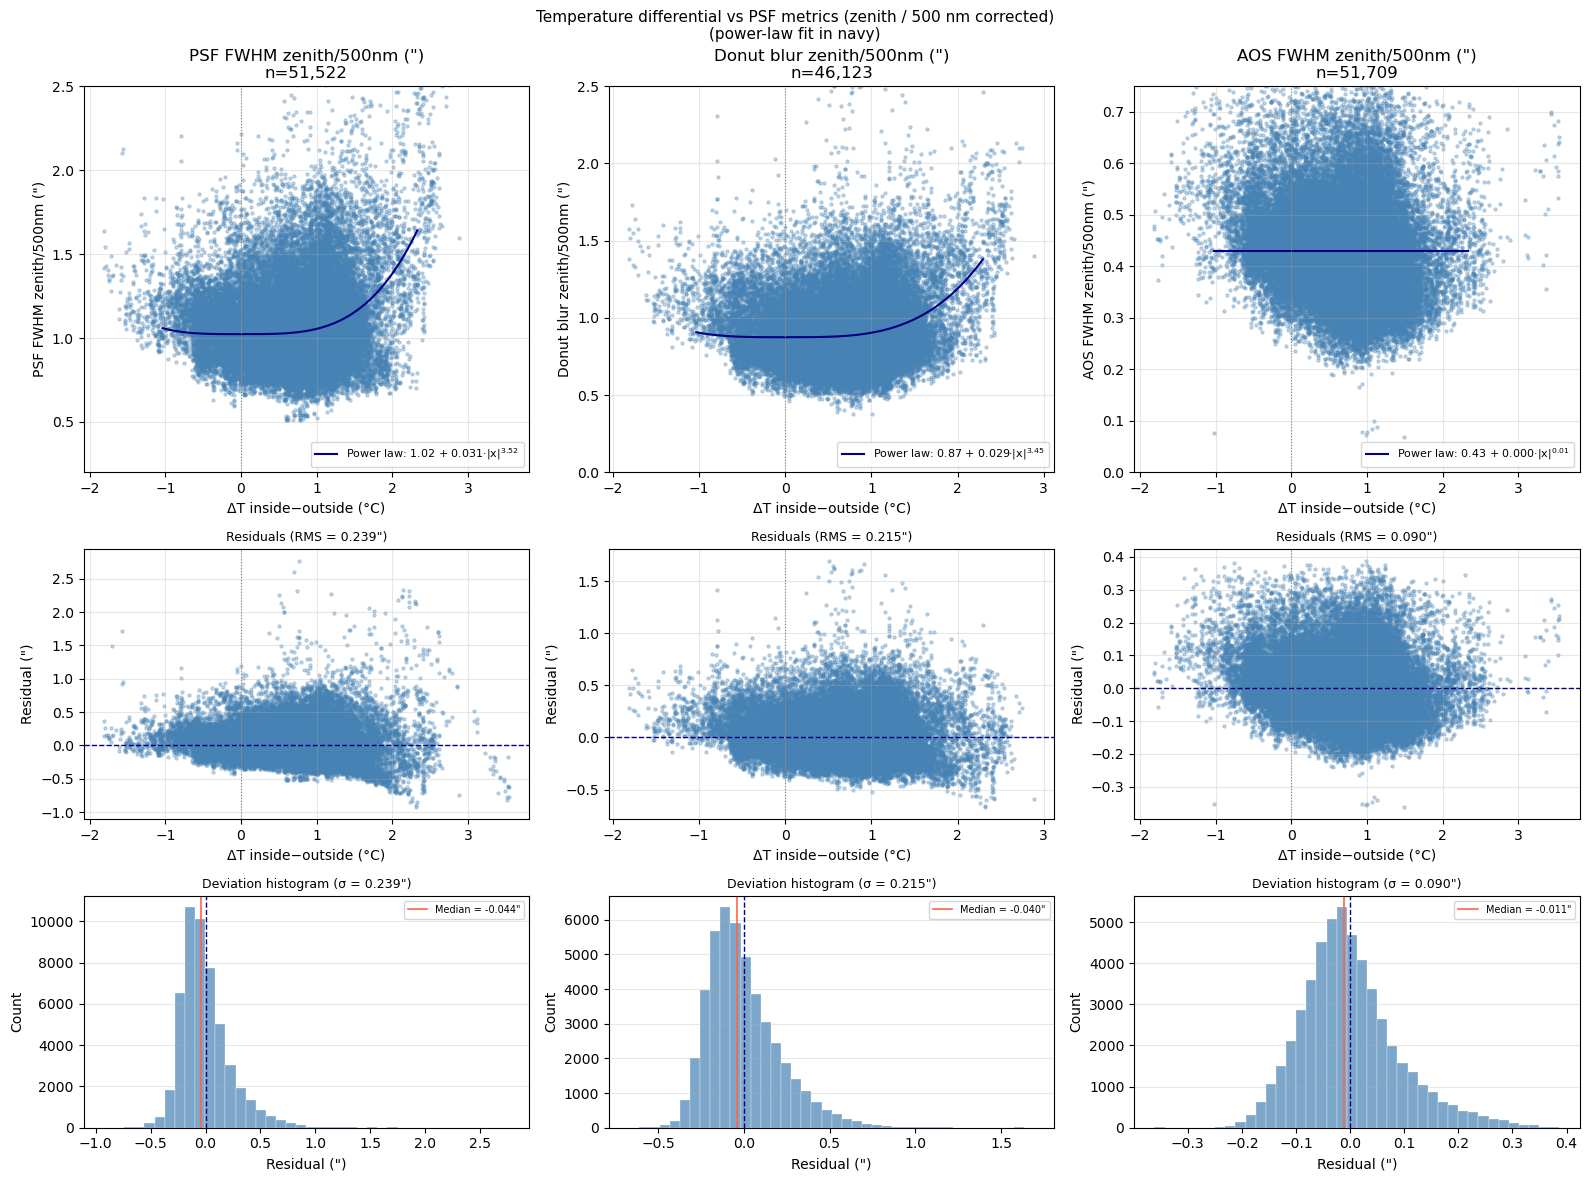

In [19]:
# Metrics used in all scatter plots (sections 7–10).
# Using elevation + wavelength corrected values (zenith / 500 nm) so all metrics
# are on a consistent basis and directly comparable to the DIMM.
psf_metrics = [
    ("psf_fwhm_zenith_500nm",   'PSF FWHM zenith/500nm (")',       0.2, 2.5),
    ("donut_blur_zenith_500nm", 'Donut blur zenith/500nm (")',      0.0, 2.5),
    ("aos_fwhm_zenith_500nm",   'AOS FWHM zenith/500nm (")',       0.0, AOS_FWHM_MAX),
]

from scipy.optimize import curve_fit as _curve_fit

def _pl_model(x, a, b, c):
    return a * np.abs(x) ** b + c

def _pl_fit(x_arr, y_arr, x_line):
    """Fit y = a·|x|^b + c (power law on |x|); return (y_line, label, popt) or (None, None, None)."""
    try:
        p0 = [0.05, 0.5, float(np.nanmedian(y_arr))]
        popt, _ = _curve_fit(_pl_model, x_arr, y_arr, p0=p0, maxfev=10000,
                             bounds=([0, 0.01, 0], [20, 6, 5]))
        lbl = fr"Power law: {popt[2]:.2f} + {popt[0]:.3f}·|x|$^{{{popt[1]:.2f}}}$"
        return _pl_model(x_line, *popt), lbl, popt
    except Exception:
        return None, None, None

fig, axes = plt.subplots(3, 3, figsize=(16, 12), height_ratios=[1, 0.7, 0.6])

for col, (metric, ylabel, ymin, ymax) in enumerate(psf_metrics):
    ax = axes[0, col]
    ax_res = axes[1, col]
    ax_hist = axes[2, col]
    sub = df_iq.dropna(subset=[metric, "delta_T_best"])
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(ylabel)
        ax_res.set_visible(False)
        ax_hist.set_visible(False)
        continue

    ax.scatter(
        sub["delta_T_best"], sub[metric],
        color="steelblue", s=5, alpha=0.3,
    )

    # ── power-law fit: y = a·|x|^b + c ────────────────────────────
    _x = sub["delta_T_best"].values
    _y = sub[metric].values
    _x_lo, _x_hi = np.nanpercentile(_x, [0.5, 99.5])
    _x_line = np.linspace(_x_lo, _x_hi, 300)
    _y_fit, _fit_lbl, _popt = _pl_fit(_x, _y, _x_line)
    if _y_fit is not None:
        ax.plot(_x_line, _y_fit, color="navy", lw=1.5, label=_fit_lbl)
        residuals = _y - _pl_model(_x, *_popt)
        ax_res.scatter(_x, residuals, color="steelblue", s=5, alpha=0.3)
        ax_res.axhline(0, color="navy", lw=1.0, ls="--")
        rms = np.sqrt(np.nanmean(residuals**2))
        ax_res.set_title(f'Residuals (RMS = {rms:.3f}")', fontsize=9)

        ax_hist.hist(residuals, bins=40, color="steelblue", alpha=0.7, edgecolor="white", lw=0.3)
        ax_hist.axvline(0, color="navy", lw=1.0, ls="--")
        ax_hist.axvline(np.nanmedian(residuals), color="tomato", lw=1.2, ls="-",
                        label=f"Median = {np.nanmedian(residuals):.3f}\"")
        ax_hist.set_xlabel('Residual (")')
        ax_hist.set_ylabel("Count")
        ax_hist.set_title(f"Deviation histogram (σ = {np.nanstd(residuals):.3f}\")", fontsize=9)
        ax_hist.legend(fontsize=7)
        ax_hist.grid(True, alpha=0.3, axis="y")
    else:
        ax_res.text(0.5, 0.5, "No fit", ha="center", va="center", transform=ax_res.transAxes)
        ax_hist.set_visible(False)

    ax.set_xlabel("ΔT inside−outside (°C)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ymin, ymax)
    ax.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax.set_title(f"{ylabel}\nn={len(sub):,}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax_res.set_xlabel("ΔT inside−outside (°C)")
    ax_res.set_ylabel('Residual (")')
    ax_res.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax_res.grid(True, alpha=0.3)

fig.suptitle("Temperature differential vs PSF metrics (zenith / 500 nm corrected)\n"
             "(power-law fit in navy)",
             fontsize=11)
plt.tight_layout()


## 8. Intra-Dome Gradient vs PSF Metrics

ESS:111 (camera inlet) − ESS:113 (M1M3 vicinity) gives a rough proxy for the
vertical temperature stratification inside the dome, which can drive dome seeing.


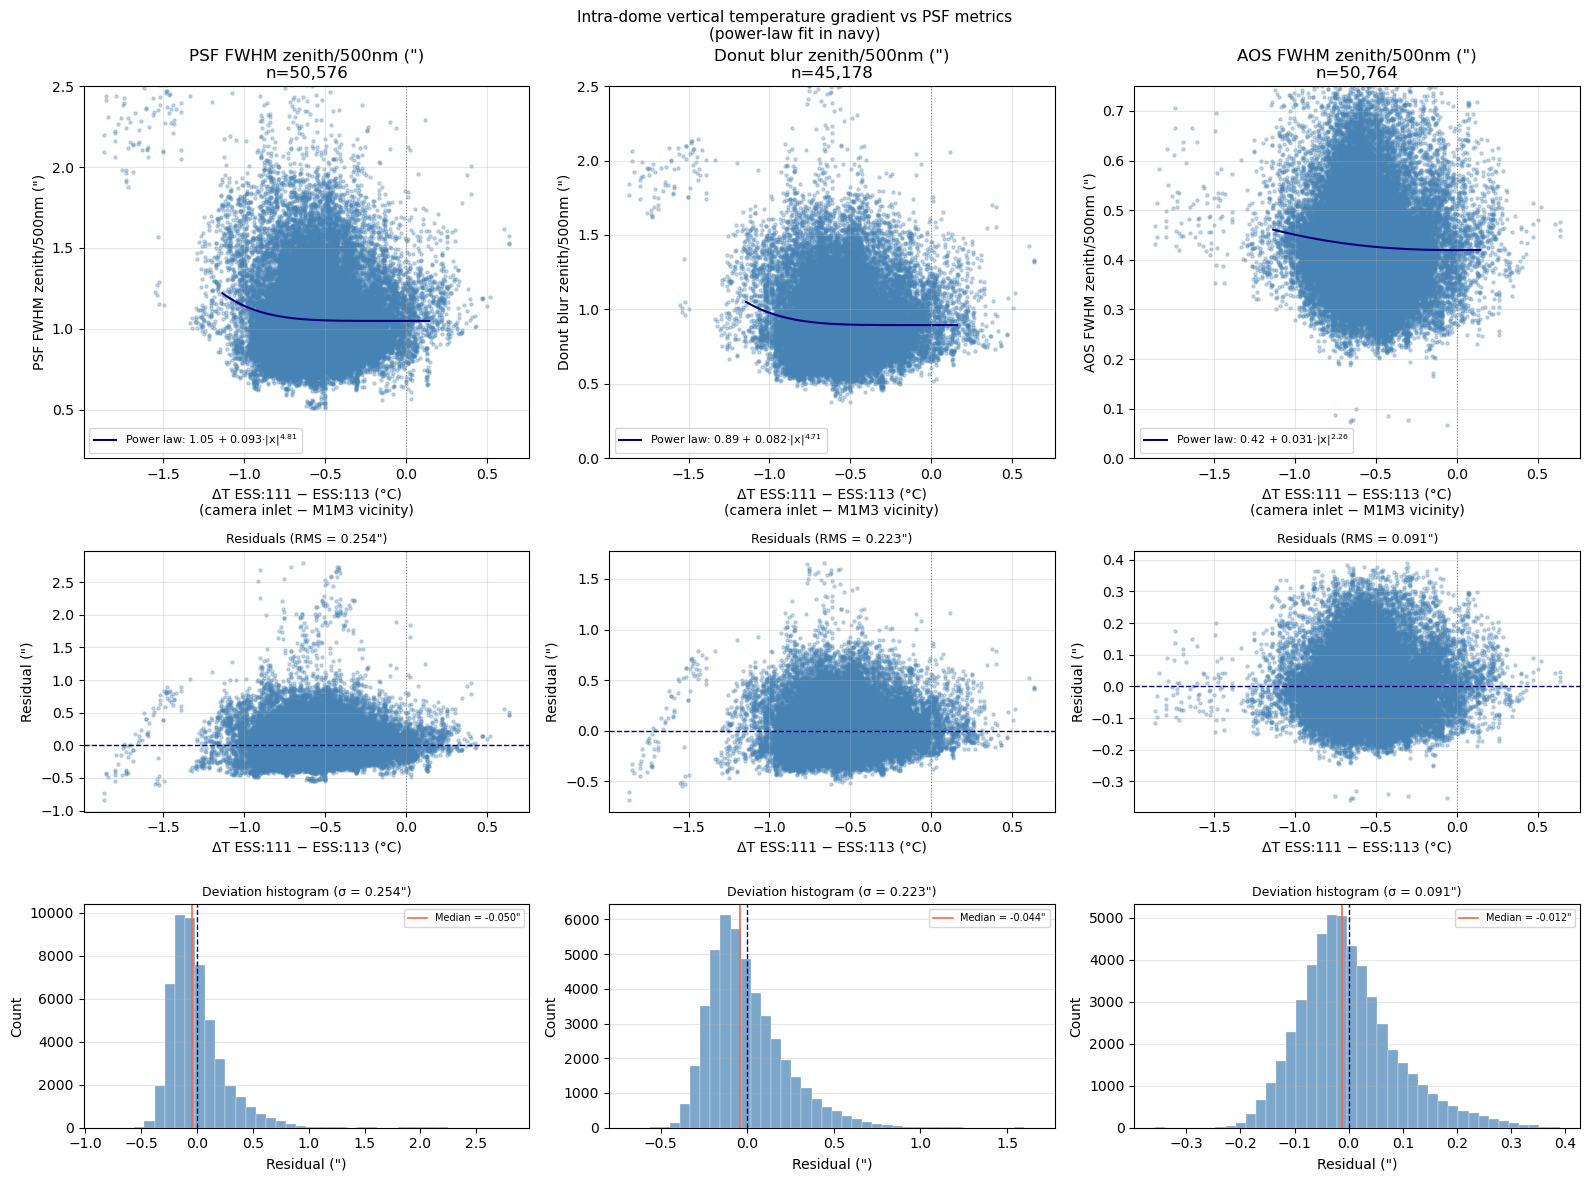

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), height_ratios=[1, 0.7, 0.6])

for col, (metric, ylabel, ymin, ymax) in enumerate(psf_metrics):
    ax = axes[0, col]
    ax_res = axes[1, col]
    ax_hist = axes[2, col]
    sub = df_iq.dropna(subset=[metric, "delta_T_111_113"])
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(ylabel)
        ax_res.set_visible(False)
        ax_hist.set_visible(False)
        continue

    ax.scatter(
        sub["delta_T_111_113"], sub[metric],
        color="steelblue", s=5, alpha=0.3,
    )

    _x = sub["delta_T_111_113"].values
    _y = sub[metric].values
    _x_lo, _x_hi = np.nanpercentile(_x, [0.5, 99.5])
    _x_line = np.linspace(_x_lo, _x_hi, 300)
    _y_fit, _fit_lbl, _popt = _pl_fit(_x, _y, _x_line)
    if _y_fit is not None:
        ax.plot(_x_line, _y_fit, color="navy", lw=1.5, label=_fit_lbl)
        residuals = _y - _pl_model(_x, *_popt)
        ax_res.scatter(_x, residuals, color="steelblue", s=5, alpha=0.3)
        ax_res.axhline(0, color="navy", lw=1.0, ls="--")
        rms = np.sqrt(np.nanmean(residuals**2))
        ax_res.set_title(f'Residuals (RMS = {rms:.3f}")', fontsize=9)

        ax_hist.hist(residuals, bins=40, color="steelblue", alpha=0.7, edgecolor="white", lw=0.3)
        ax_hist.axvline(0, color="navy", lw=1.0, ls="--")
        ax_hist.axvline(np.nanmedian(residuals), color="tomato", lw=1.2, ls="-",
                        label=f"Median = {np.nanmedian(residuals):.3f}\"")
        ax_hist.set_xlabel('Residual (")')
        ax_hist.set_ylabel("Count")
        ax_hist.set_title(f"Deviation histogram (σ = {np.nanstd(residuals):.3f}\")", fontsize=9)
        ax_hist.legend(fontsize=7)
        ax_hist.grid(True, alpha=0.3, axis="y")
    else:
        ax_res.text(0.5, 0.5, "No fit", ha="center", va="center", transform=ax_res.transAxes)
        ax_hist.set_visible(False)

    ax.set_xlabel("ΔT ESS:111 − ESS:113 (°C)\n(camera inlet − M1M3 vicinity)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ymin, ymax)
    ax.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax.set_title(f"{ylabel}\nn={len(sub):,}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax_res.set_xlabel("ΔT ESS:111 − ESS:113 (°C)")
    ax_res.set_ylabel('Residual (")')
    ax_res.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax_res.grid(True, alpha=0.3)

fig.suptitle("Intra-dome vertical temperature gradient vs PSF metrics\n"
             "(power-law fit in navy)",
             fontsize=11)
plt.tight_layout()


## 9. Turbulence Speed vs PSF Metrics

ESS:110 `speedMagnitude` from the TMA platform sonic anemometer is the best
available in-dome turbulence proxy.


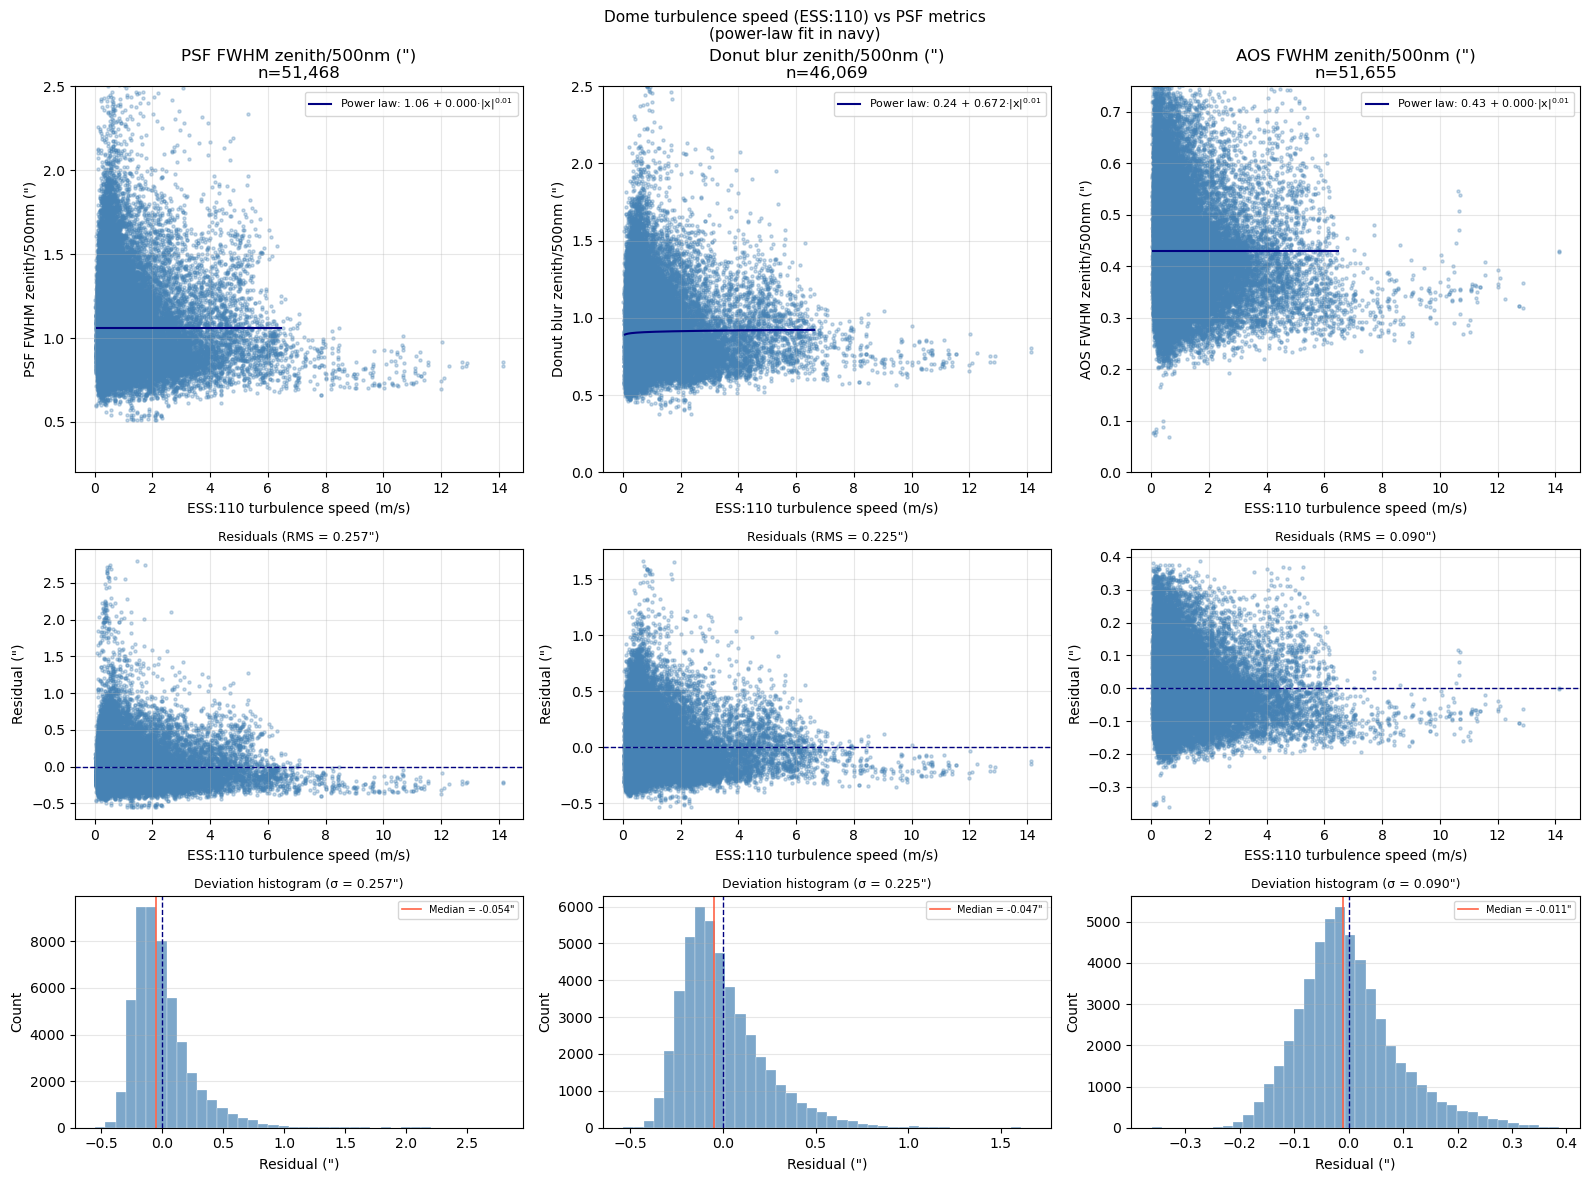

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), height_ratios=[1, 0.7, 0.6])

for col, (metric, ylabel, ymin, ymax) in enumerate(psf_metrics):
    ax = axes[0, col]
    ax_res = axes[1, col]
    ax_hist = axes[2, col]
    sub = df_iq.dropna(subset=[metric, "turb_speed_110"])
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(ylabel)
        ax_res.set_visible(False)
        ax_hist.set_visible(False)
        continue

    ax.scatter(
        sub["turb_speed_110"], sub[metric],
        color="steelblue", s=5, alpha=0.3,
    )

    _x = sub["turb_speed_110"].values
    _y = sub[metric].values
    _x_lo, _x_hi = np.nanpercentile(_x, [0.5, 99.5])
    _x_line = np.linspace(_x_lo, _x_hi, 300)
    _y_fit, _fit_lbl, _popt = _pl_fit(_x, _y, _x_line)
    if _y_fit is not None:
        ax.plot(_x_line, _y_fit, color="navy", lw=1.5, label=_fit_lbl)
        residuals = _y - _pl_model(_x, *_popt)
        ax_res.scatter(_x, residuals, color="steelblue", s=5, alpha=0.3)
        ax_res.axhline(0, color="navy", lw=1.0, ls="--")
        rms = np.sqrt(np.nanmean(residuals**2))
        ax_res.set_title(f'Residuals (RMS = {rms:.3f}")', fontsize=9)

        ax_hist.hist(residuals, bins=40, color="steelblue", alpha=0.7, edgecolor="white", lw=0.3)
        ax_hist.axvline(0, color="navy", lw=1.0, ls="--")
        ax_hist.axvline(np.nanmedian(residuals), color="tomato", lw=1.2, ls="-",
                        label=f"Median = {np.nanmedian(residuals):.3f}\"")
        ax_hist.set_xlabel('Residual (")')
        ax_hist.set_ylabel("Count")
        ax_hist.set_title(f"Deviation histogram (σ = {np.nanstd(residuals):.3f}\")", fontsize=9)
        ax_hist.legend(fontsize=7)
        ax_hist.grid(True, alpha=0.3, axis="y")
    else:
        ax_res.text(0.5, 0.5, "No fit", ha="center", va="center", transform=ax_res.transAxes)
        ax_hist.set_visible(False)

    ax.set_xlabel(f"ESS:{TURB_INDEX} turbulence speed (m/s)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{ylabel}\nn={len(sub):,}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax_res.set_xlabel(f"ESS:{TURB_INDEX} turbulence speed (m/s)")
    ax_res.set_ylabel('Residual (")')
    ax_res.grid(True, alpha=0.3)

fig.suptitle("Dome turbulence speed (ESS:110) vs PSF metrics\n"
             "(power-law fit in navy)",
             fontsize=11)
plt.tight_layout()


## 10. Mirror Glass ΔT vs PSF Metrics

`delta_T_glass_air` = `glass_temp_bulk` − `inside_temp_113` (M1M3 vicinity).
Negative values mean the glass is cooler than the local air — a classic driver
of mirror seeing through boundary-layer convection.


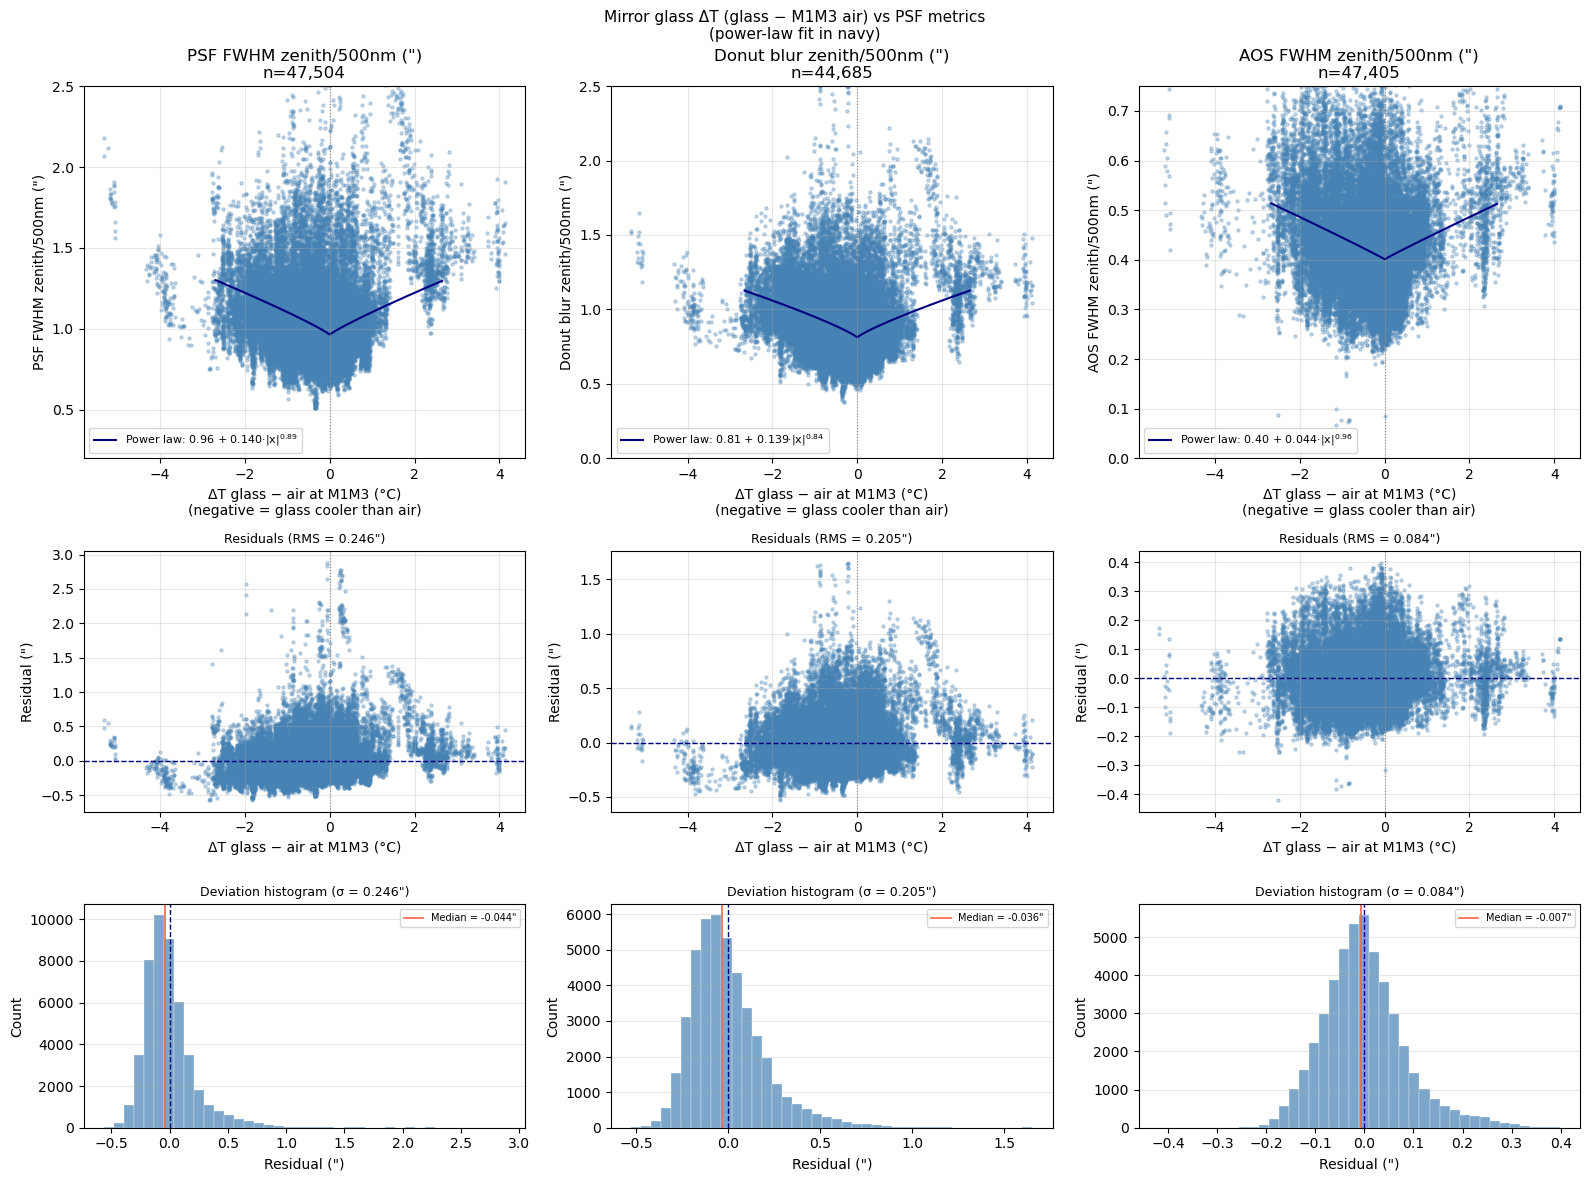

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12), height_ratios=[1, 0.7, 0.6])

for col, (metric, ylabel, ymin, ymax) in enumerate(psf_metrics):
    ax = axes[0, col]
    ax_res = axes[1, col]
    ax_hist = axes[2, col]
    sub = df_iq.dropna(subset=[metric, "delta_T_glass_air"])
    if sub.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(ylabel)
        ax_res.set_visible(False)
        ax_hist.set_visible(False)
        continue

    ax.scatter(
        sub["delta_T_glass_air"], sub[metric],
        color="steelblue", s=5, alpha=0.3,
    )

    _x = sub["delta_T_glass_air"].values
    _y = sub[metric].values
    _x_lo, _x_hi = np.nanpercentile(_x, [0.5, 99.5])
    _x_line = np.linspace(_x_lo, _x_hi, 300)
    _y_fit, _fit_lbl, _popt = _pl_fit(_x, _y, _x_line)
    if _y_fit is not None:
        ax.plot(_x_line, _y_fit, color="navy", lw=1.5, label=_fit_lbl)
        residuals = _y - _pl_model(_x, *_popt)
        ax_res.scatter(_x, residuals, color="steelblue", s=5, alpha=0.3)
        ax_res.axhline(0, color="navy", lw=1.0, ls="--")
        rms = np.sqrt(np.nanmean(residuals**2))
        ax_res.set_title(f'Residuals (RMS = {rms:.3f}")', fontsize=9)

        ax_hist.hist(residuals, bins=40, color="steelblue", alpha=0.7, edgecolor="white", lw=0.3)
        ax_hist.axvline(0, color="navy", lw=1.0, ls="--")
        ax_hist.axvline(np.nanmedian(residuals), color="tomato", lw=1.2, ls="-",
                        label=f"Median = {np.nanmedian(residuals):.3f}\"")
        ax_hist.set_xlabel('Residual (")')
        ax_hist.set_ylabel("Count")
        ax_hist.set_title(f"Deviation histogram (σ = {np.nanstd(residuals):.3f}\")", fontsize=9)
        ax_hist.legend(fontsize=7)
        ax_hist.grid(True, alpha=0.3, axis="y")
    else:
        ax_res.text(0.5, 0.5, "No fit", ha="center", va="center", transform=ax_res.transAxes)
        ax_hist.set_visible(False)

    ax.set_xlabel("ΔT glass − air at M1M3 (°C)\n(negative = glass cooler than air)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ymin, ymax)
    ax.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax.set_title(f"{ylabel}\nn={len(sub):,}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax_res.set_xlabel("ΔT glass − air at M1M3 (°C)")
    ax_res.set_ylabel('Residual (")')
    ax_res.axvline(0, color="grey", lw=0.8, linestyle=":")
    ax_res.grid(True, alpha=0.3)

fig.suptitle("Mirror glass ΔT (glass − M1M3 air) vs PSF metrics\n"
             "(power-law fit in navy)",
             fontsize=11)
plt.tight_layout()


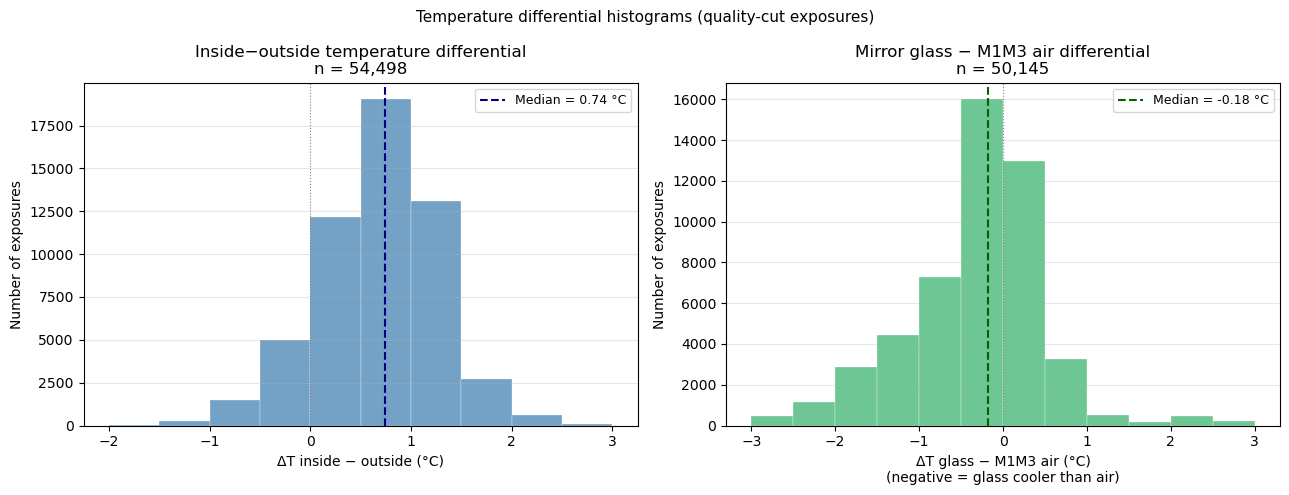

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: ΔT inside − outside ─────────────────────────────────────────────
ax = axes[0]
s_in_out = df_iq["delta_T_best"].dropna()
bins_in_out = np.arange(np.floor(s_in_out.quantile(0.005)),
                         np.ceil(s_in_out.quantile(0.995)) + 0.5, 0.5)
ax.hist(s_in_out, bins=bins_in_out, color="steelblue", alpha=0.75, edgecolor="white", lw=0.3)
ax.axvline(s_in_out.median(), color="navy", lw=1.5, linestyle="--",
           label=f"Median = {s_in_out.median():.2f} °C")
ax.axvline(0, color="grey", lw=0.8, linestyle=":")
ax.set_xlabel("ΔT inside − outside (°C)")
ax.set_ylabel("Number of exposures")
ax.set_title(f"Inside−outside temperature differential\nn = {len(s_in_out):,}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# ── Panel 2: ΔT glass − air at M1M3 ─────────────────────────────────────────
ax = axes[1]
s_glass = df_iq["delta_T_glass_air"].dropna()
bins_glass = np.arange(np.floor(s_glass.quantile(0.005)),
                        np.ceil(s_glass.quantile(0.995)) + 0.5, 0.5)
ax.hist(s_glass, bins=bins_glass, color="mediumseagreen", alpha=0.75, edgecolor="white", lw=0.3)
ax.axvline(s_glass.median(), color="darkgreen", lw=1.5, linestyle="--",
           label=f"Median = {s_glass.median():.2f} °C")
ax.axvline(0, color="grey", lw=0.8, linestyle=":")
ax.set_xlabel("ΔT glass − M1M3 air (°C)\n(negative = glass cooler than air)")
ax.set_ylabel("Number of exposures")
ax.set_title(f"Mirror glass − M1M3 air differential\nn = {len(s_glass):,}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Temperature differential histograms (quality-cut exposures)", fontsize=11)
plt.tight_layout()
plt.show()


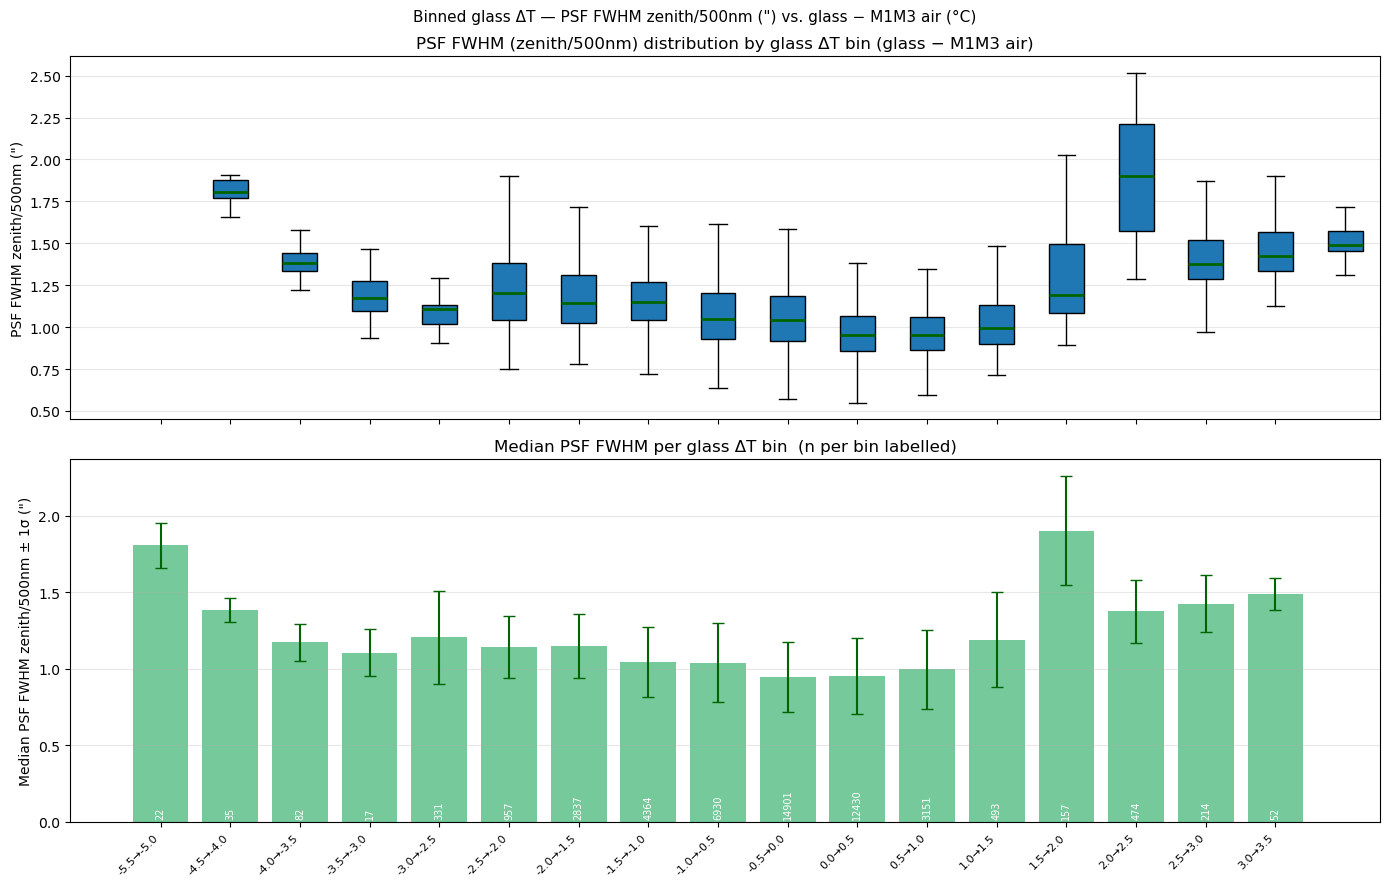


Binned summary (glass ΔT):


,glass_bin,psf_fwhm_median,psf_fwhm_std,n
0,-5.5→-5.0,1.807838,0.146021,22
1,-4.5→-4.0,1.384535,0.078600,35
2,-4.0→-3.5,1.172953,0.119247,82
3,-3.5→-3.0,1.105717,0.152962,17
4,-3.0→-2.5,1.205787,0.302814,331
5,-2.5→-2.0,1.141302,0.201916,957
6,-2.0→-1.5,1.147628,0.208506,2837
7,-1.5→-1.0,1.046639,0.229664,4364
8,-1.0→-0.5,1.040383,0.259411,6930
9,-0.5→0.0,0.950076,0.228428,14901


In [24]:

glass_bins   = np.arange(-6, 4, 0.5)    # 0.5 °C steps
glass_labels = [f"{lo:.1f}→{lo+0.5:.1f}" for lo in glass_bins[:-1]]

df_glass_binned = df_iq.dropna(subset=["delta_T_glass_air", "psf_fwhm_zenith_500nm"]).copy()
df_glass_binned["glass_bin"] = pd.cut(df_glass_binned["delta_T_glass_air"],
                                       bins=glass_bins, labels=glass_labels, right=True)

glass_bin_stats = df_glass_binned.groupby("glass_bin", observed=True)["psf_fwhm_zenith_500nm"].agg(
    ["median", "std", "count"]
).reset_index()
glass_bin_stats.columns = ["glass_bin", "psf_fwhm_median", "psf_fwhm_std", "n"]

fig, (ax_box, ax_med) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

valid_glass_bins = [b for b in glass_labels
                    if b in df_glass_binned["glass_bin"].cat.categories
                    and (df_glass_binned["glass_bin"] == b).sum() > 0]
glass_box_data = [df_glass_binned.loc[df_glass_binned["glass_bin"] == b,
                                       "psf_fwhm_zenith_500nm"].dropna().values
                  for b in valid_glass_bins]
ax_box.boxplot(glass_box_data, tick_labels=valid_glass_bins, showfliers=False,
               patch_artist=True, medianprops={"color": "darkgreen", "lw": 2})
ax_box.set_ylabel('PSF FWHM zenith/500nm (")')
ax_box.set_title("PSF FWHM (zenith/500nm) distribution by glass ΔT bin (glass − M1M3 air)")
ax_box.grid(True, alpha=0.3, axis="y")

valid_glass_stats = glass_bin_stats[glass_bin_stats["glass_bin"].isin(valid_glass_bins)]
x = np.arange(len(valid_glass_stats))
ax_med.bar(x, valid_glass_stats["psf_fwhm_median"], color="mediumseagreen", alpha=0.7)
ax_med.errorbar(x, valid_glass_stats["psf_fwhm_median"],
                yerr=valid_glass_stats["psf_fwhm_std"],
                fmt="none", color="darkgreen", capsize=4, lw=1.5)
ax_med.set_xticks(x)
ax_med.set_xticklabels(valid_glass_stats["glass_bin"].values, rotation=45, ha="right", fontsize=8)
ax_med.set_ylabel('Median PSF FWHM zenith/500nm ± 1σ (")')
ax_med.set_title("Median PSF FWHM per glass ΔT bin  (n per bin labelled)")
for xi, row in zip(x, valid_glass_stats.itertuples()):
    ax_med.text(xi, 0.02, str(int(row.n)), ha="center", va="bottom",
                fontsize=7, color="white", rotation=90)
ax_med.grid(True, alpha=0.3, axis="y")

fig.suptitle('Binned glass ΔT — PSF FWHM zenith/500nm (") vs. glass − M1M3 air (°C)',
             fontsize=11)
plt.tight_layout()
plt.show()

print("\nBinned summary (glass ΔT):")
display(glass_bin_stats)


## 11. Binned ΔT Analysis (inside − outside)

Bin exposures by ΔT (inside−outside) in 1 °C steps and show the distribution
of PSF σ in each bin.


/lscratch/stalder/tmp/ipykernel_2010806/1343171409.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(box_data, labels=valid_bins, showfliers=False, patch_artist=True,


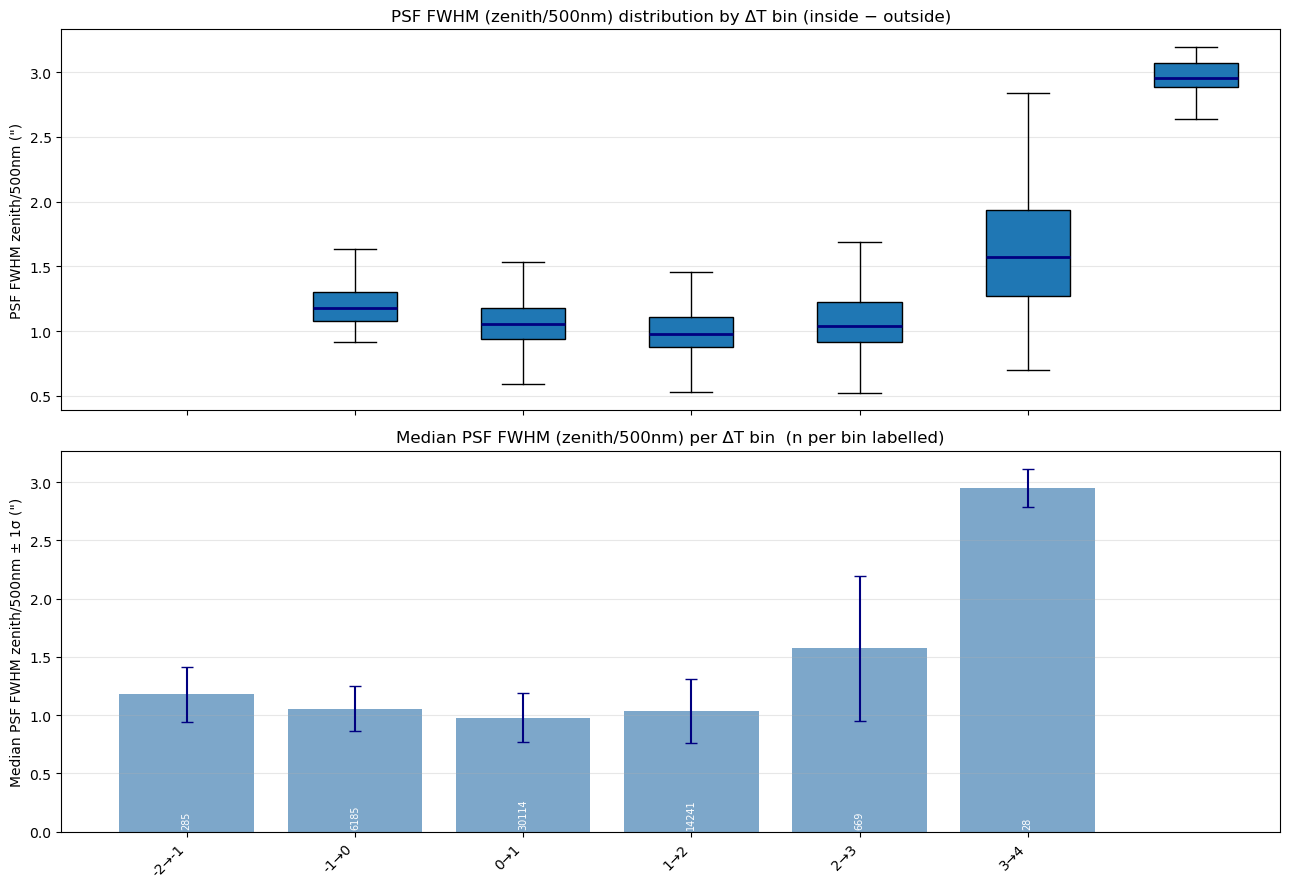


Binned summary:


,dT_bin,psf_fwhm_median,psf_fwhm_std,n
0,-2→-1,1.179701,0.237479,285
1,-1→0,1.055677,0.193503,6185
2,0→1,0.977601,0.211652,30114
3,1→2,1.037403,0.277218,14241
4,2→3,1.575235,0.623164,669
5,3→4,2.953219,0.162382,28


In [25]:

dt_bins   = np.arange(-6, 7, 1)
dt_labels = [f"{lo}→{lo+1}" for lo in dt_bins[:-1]]

df_binned = df_iq.dropna(subset=["delta_T_best", "psf_fwhm_zenith_500nm"]).copy()
df_binned["dT_bin"] = pd.cut(df_binned["delta_T_best"],
                              bins=dt_bins, labels=dt_labels, right=True)

bin_stats = df_binned.groupby("dT_bin", observed=True)["psf_fwhm_zenith_500nm"].agg(
    ["median", "std", "count"]
).reset_index()
bin_stats.columns = ["dT_bin", "psf_fwhm_median", "psf_fwhm_std", "n"]

fig, (ax_box, ax_med) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

valid_bins = [b for b in dt_labels
              if b in df_binned["dT_bin"].cat.categories
              and (df_binned["dT_bin"] == b).sum() > 0]
box_data  = [df_binned.loc[df_binned["dT_bin"] == b, "psf_fwhm_zenith_500nm"].dropna().values
             for b in valid_bins]
ax_box.boxplot(box_data, labels=valid_bins, showfliers=False, patch_artist=True,
               medianprops={"color": "navy", "lw": 2})
ax_box.set_ylabel('PSF FWHM zenith/500nm (")')
ax_box.set_title("PSF FWHM (zenith/500nm) distribution by ΔT bin (inside − outside)")
ax_box.grid(True, alpha=0.3, axis="y")

valid_stats = bin_stats[bin_stats["dT_bin"].isin(valid_bins)]
x = np.arange(len(valid_stats))
ax_med.bar(x, valid_stats["psf_fwhm_median"], color="steelblue", alpha=0.7)
ax_med.errorbar(x, valid_stats["psf_fwhm_median"],
                yerr=valid_stats["psf_fwhm_std"],
                fmt="none", color="navy", capsize=4, lw=1.5)
ax_med.set_xticks(x)
ax_med.set_xticklabels(valid_stats["dT_bin"].values, rotation=45, ha="right")
ax_med.set_ylabel('Median PSF FWHM zenith/500nm ± 1σ (")')
ax_med.set_title("Median PSF FWHM (zenith/500nm) per ΔT bin  (n per bin labelled)")
for xi, row in zip(x, valid_stats.itertuples()):
    ax_med.text(xi, 0.02, str(int(row.n)), ha="center", va="bottom",
                fontsize=7, color="white", rotation=90)
ax_med.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nBinned summary:")
display(bin_stats)


## 12. Correlation Matrix

Spearman rank correlations between all thermal/PSF variables.


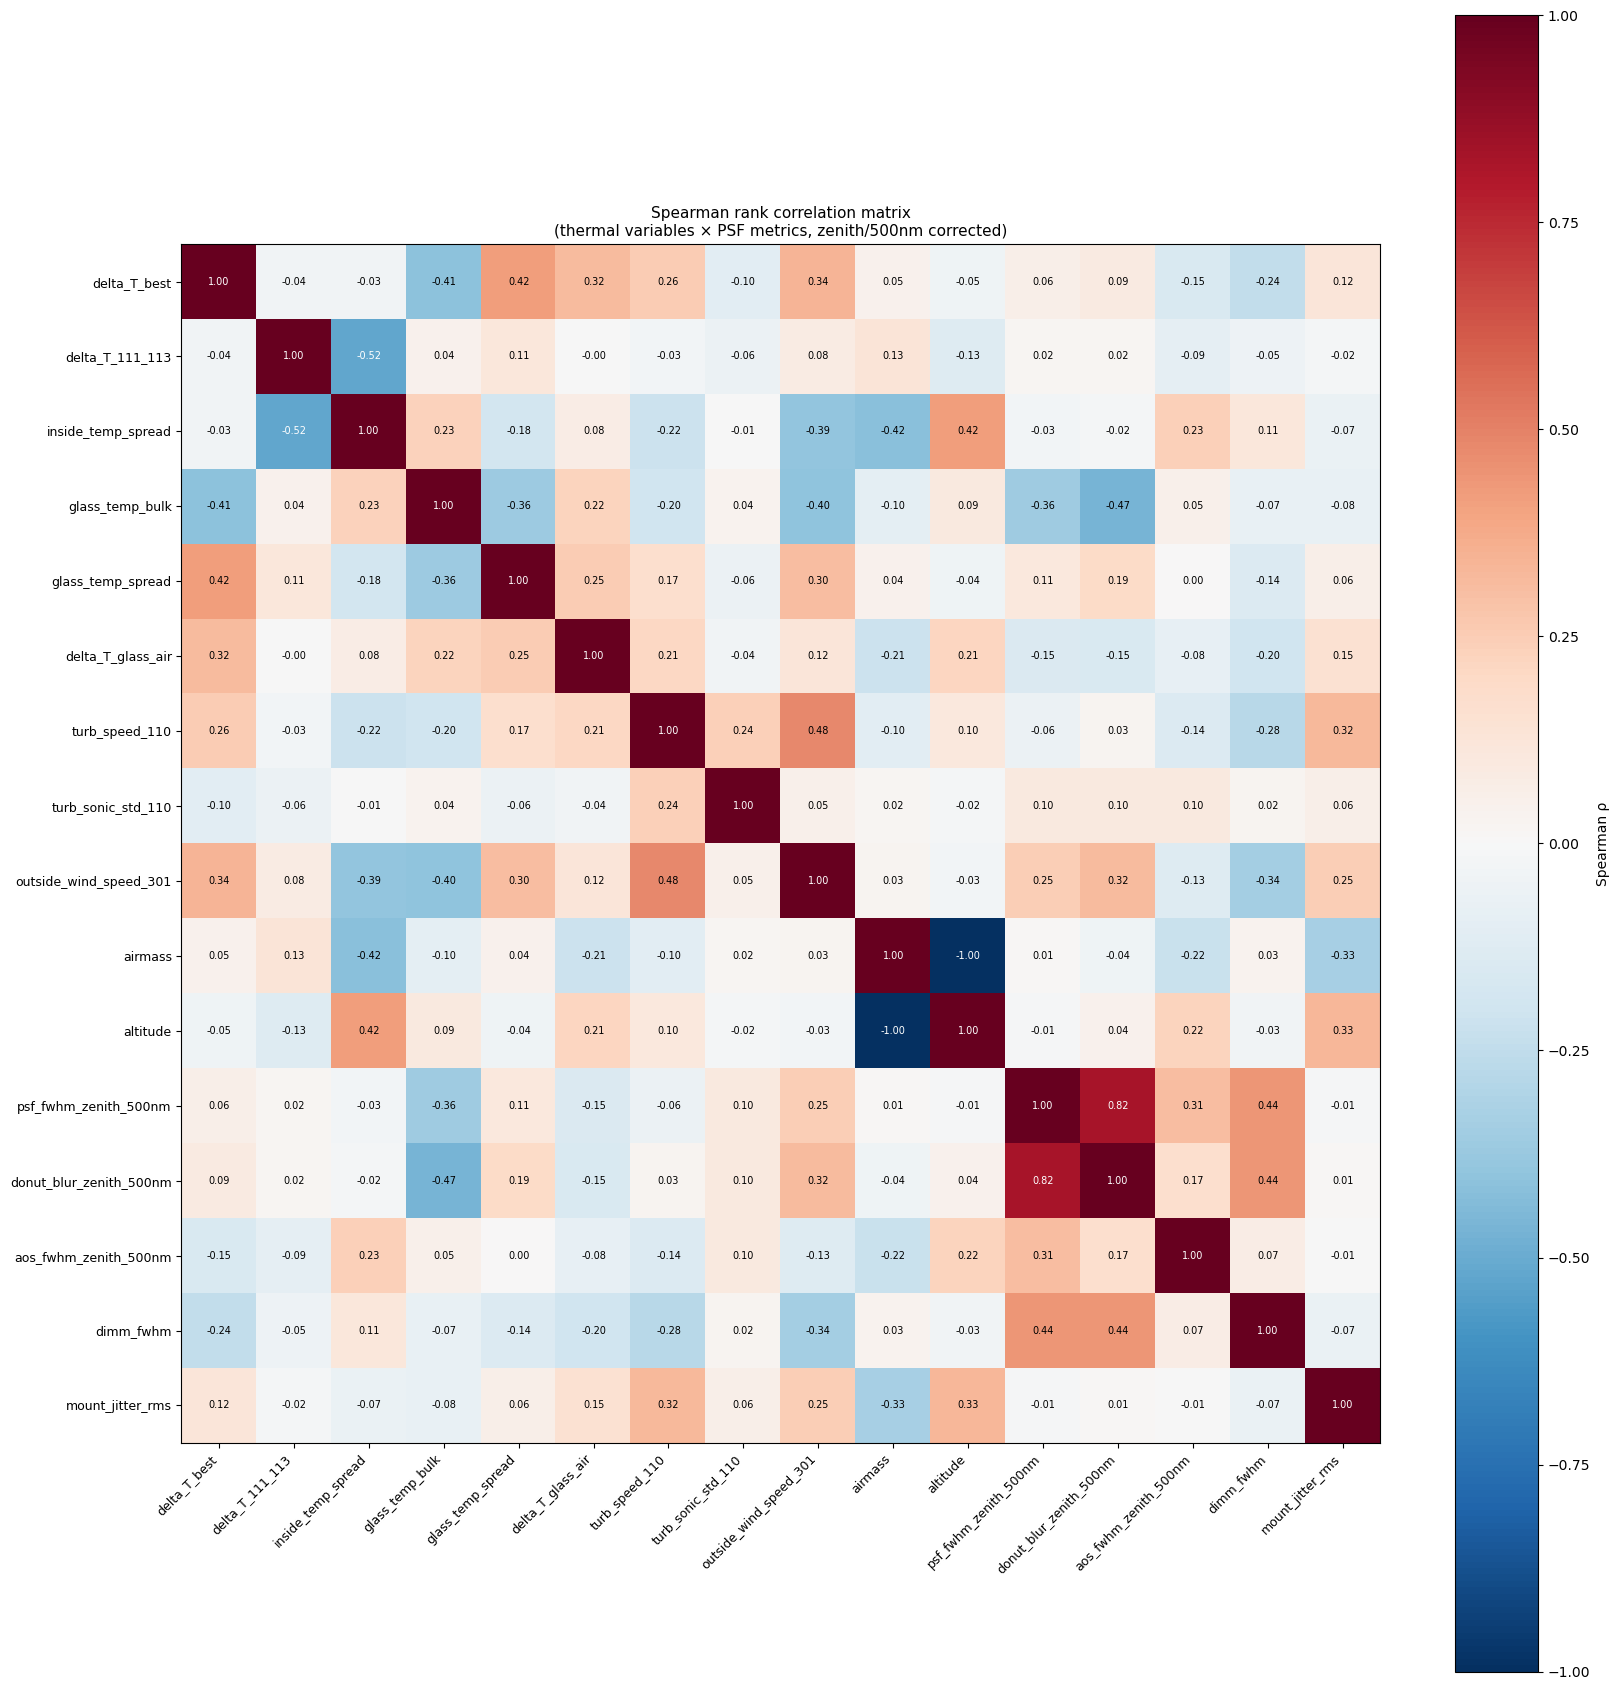

In [26]:

corr_cols = [
    "delta_T_best",
    "delta_T_111_113",
    "inside_temp_spread",
    "glass_temp_bulk",
    "glass_temp_spread",
    "delta_T_glass_air",
    "turb_speed_110",
    "turb_sonic_std_110",
    "outside_wind_speed_301",
    "airmass",
    "altitude",
    "psf_fwhm_zenith_500nm",
    "donut_blur_zenith_500nm",
    "aos_fwhm_zenith_500nm",
    "dimm_fwhm",
    "seeing_zenith_500nm_median",
    "mount_jitter_rms",
]

# Keep columns that exist and have enough data
avail_cols = [c for c in corr_cols if c in df_iq.columns
              and df_iq[c].notna().sum() > 30]

df_corr = df_iq[avail_cols].dropna(how="all")
spearman_r = df_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(len(avail_cols) + 1, len(avail_cols) + 1))
im = ax.imshow(spearman_r.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Spearman ρ")

ax.set_xticks(range(len(avail_cols)))
ax.set_yticks(range(len(avail_cols)))
ax.set_xticklabels(avail_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(avail_cols, fontsize=9)

for i in range(len(avail_cols)):
    for j in range(len(avail_cols)):
        val = spearman_r.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color="white" if abs(val) > 0.5 else "black")

ax.set_title("Spearman rank correlation matrix\n"
             "(thermal variables × PSF metrics, zenith/500nm corrected)", fontsize=11)

plt.tight_layout()
plt.show()


## 13. Statistical Summary Table


## 14. PSF vs DIMM — Atmospheric + Dome Excess

Compare `psf_fwhm_zenith_500nm` (corrected science-image PSF) with `dimm_fwhm`
(free-atmosphere seeing from the DIMM, already at zenith/500nm).

The **PSF excess** = PSF − DIMM captures all non-atmospheric broadening:
dome seeing, mirror seeing, telescope aberrations, tracking jitter.  
Positive excess that correlates with ΔT points directly to dome/mirror thermal effects.

Exposures with PSF + DIMM overlap: 35,408
  PSF zenith/500nm  : median=1.017 arcsec
  DIMM fwhm         : median=0.984 arcsec
  Dome quadrature   : median=0.277 arcsec


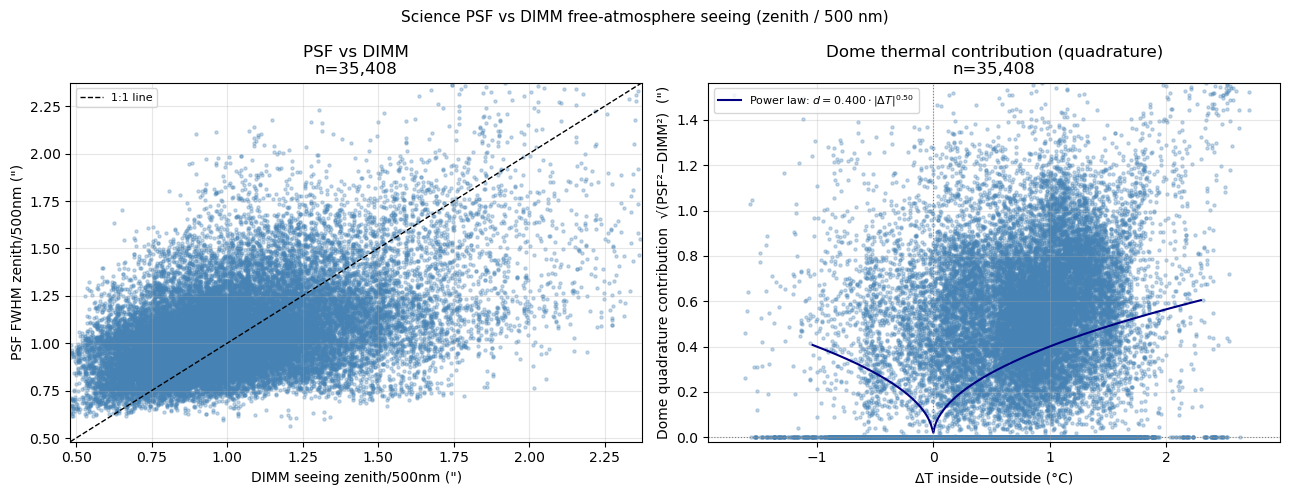

In [27]:
# ── PSF excess = PSF zenith/500nm − DIMM seeing ───────────────────────────────
DIMM_MAX = 4.0    # arcsec — clip spurious DIMM measurements
sub_dimm = df_iq.dropna(subset=["psf_fwhm_zenith_500nm", "dimm_fwhm"]).copy()
sub_dimm = sub_dimm[sub_dimm["dimm_fwhm"] <= DIMM_MAX]
sub_dimm["psf_excess"] = sub_dimm["psf_fwhm_zenith_500nm"] - sub_dimm["dimm_fwhm"]
# Quadrature dome contribution: PSF² = DIMM² + dome²  →  dome = √(PSF² − DIMM²)
sub_dimm["dome_quad"] = np.sqrt(np.maximum(0.0,
    sub_dimm["psf_fwhm_zenith_500nm"]**2 - sub_dimm["dimm_fwhm"]**2))

if sub_dimm.empty:
    print("No exposures with both PSF and DIMM data — skipping DIMM comparison plots.")
    print("Check that DIMM_TOPIC / DIMM_INDEX in the config cell are correct.")
else:
    print(f"Exposures with PSF + DIMM overlap: {len(sub_dimm):,}")
    print(f"  PSF zenith/500nm  : median={sub_dimm['psf_fwhm_zenith_500nm'].median():.3f} arcsec")
    print(f"  DIMM fwhm         : median={sub_dimm['dimm_fwhm'].median():.3f} arcsec")
    print(f"  Dome quadrature   : median={sub_dimm['dome_quad'].median():.3f} arcsec")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Panel 1: PSF vs DIMM scatter with 1:1 line ──────────────────────────
    ax = axes[0]
    ax.scatter(sub_dimm["dimm_fwhm"], sub_dimm["psf_fwhm_zenith_500nm"],
               color="steelblue", s=5, alpha=0.3)
    p_lo = min(sub_dimm["dimm_fwhm"].quantile(0.005),
               sub_dimm["psf_fwhm_zenith_500nm"].quantile(0.005)) * 0.9
    p_hi = max(sub_dimm["dimm_fwhm"].quantile(0.995),
               sub_dimm["psf_fwhm_zenith_500nm"].quantile(0.995)) * 1.05
    lims = [max(0, p_lo), p_hi]
    ax.plot(lims, lims, "k--", lw=1, label="1:1 line", zorder=5)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('DIMM seeing zenith/500nm (")')
    ax.set_ylabel('PSF FWHM zenith/500nm (")')
    ax.set_title(f'PSF vs DIMM\nn={len(sub_dimm):,}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Panel 2: Quadrature dome contribution vs ΔT ──────────────────────────
    ax = axes[1]
    sorted_s = sub_dimm.dropna(subset=["delta_T_best"]).sort_values("delta_T_best")
    ax.scatter(sorted_s["delta_T_best"], sorted_s["dome_quad"],
               color="steelblue", s=5, alpha=0.3)

    _x = sorted_s["delta_T_best"].values
    _y_dq = sorted_s["dome_quad"].values
    _x_lo, _x_hi = np.nanpercentile(_x, [0.5, 99.5])
    _x_line = np.linspace(_x_lo, _x_hi, 300)
    try:
        from scipy.optimize import curve_fit as _curve_fit
        def _pl_dome(x, d, alpha):
            return d * np.abs(x)**alpha
        _popt_dq, _ = _curve_fit(_pl_dome, _x, _y_dq, p0=[0.1, 0.6],
                                  bounds=([0, 0.01], [5, 6]), maxfev=10000)
        _d_dq, _alpha_dq = _popt_dq
        ax.plot(_x_line, _pl_dome(_x_line, *_popt_dq), color="navy", lw=1.5,
                label=fr"Power law: $d={_d_dq:.3f} \cdot |{{\Delta T}}|^{{{_alpha_dq:.2f}}}$")
    except Exception:
        pass
    ax.axhline(0, color="grey", lw=0.8, linestyle=":")
    ax.axvline(0, color="grey", lw=0.8, linestyle=":")
    dq_hi = sorted_s["dome_quad"].quantile(0.995)
    ax.set_ylim(-0.02, dq_hi * 1.1)
    ax.set_xlabel("ΔT inside−outside (°C)")
    ax.set_ylabel('Dome quadrature contribution  √(PSF²−DIMM²)  (")')
    ax.set_title(f"Dome thermal contribution (quadrature)\nn={len(sorted_s):,}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle("Science PSF vs DIMM free-atmosphere seeing (zenith / 500 nm)",
                 fontsize=11)
    plt.tight_layout()
    plt.show()


In [28]:

summary_cols = [
    ("delta_T_best",               "ΔT inside−outside (°C)"),
    ("delta_T_111_113",            "ΔT ESS:111−113 (°C)"),
    ("inside_temp_spread",         "Inside temp spread std (°C)"),
    ("turb_speed_110",             "Turb. speed ESS:110 (m/s)"),
    ("turb_sonic_std_110",         "Sonic temp std ESS:110 (°C)"),
    ("outside_wind_speed_301",     "Outside wind speed ESS:301 (m/s)"),
    ("psf_fwhm_arcsec",            'PSF FWHM observed (")'),
    ("psf_fwhm_zenith_500nm",      'PSF FWHM zenith/500nm (")'),
    ("donut_blur_zenith_500nm",    'Donut blur zenith/500nm (")'),
    ("aos_fwhm_zenith_500nm",      'AOS FWHM zenith/500nm (")'),
    ("dimm_fwhm",                  'DIMM seeing zenith/500nm (")'),
    ("seeing_zenith_500nm_median", "ConsDB zenith seeing 500nm (arcsec)"),
    ("glass_temp_bulk",            "Mirror glass bulk temp (°C)"),
    ("glass_temp_spread",          "Mirror glass spread std (°C)"),
    ("delta_T_glass_air",          "ΔT glass−air (°C)"),
]

rows = []
for col, label in summary_cols:
    if col not in df_iq.columns:
        continue
    s = df_iq[col].dropna()
    rows.append({
        "Variable":   label,
        "N valid":    len(s),
        "Mean":       round(s.mean(), 3),
        "Std":        round(s.std(), 3),
        "Median":     round(s.median(), 3),
        "p5":         round(s.quantile(0.05), 3),
        "p95":        round(s.quantile(0.95), 3),
    })

df_summary = pd.DataFrame(rows).set_index("Variable")
display(df_summary)


,N valid,Mean,Std,Median,p5,p95
Variable,,,,,,
ΔT inside−outside (°C),54498,0.686,0.592,0.738,-0.380,1.558
ΔT ESS:111−113 (°C),53549,-0.554,0.213,-0.563,-0.870,-0.179
Inside temp spread std (°C),53549,0.686,0.160,0.675,0.440,0.970
Turb. speed ESS:110 (m/s),54441,1.104,1.296,0.630,0.138,3.654
Sonic temp std ESS:110 (°C),54441,0.046,0.022,0.039,0.024,0.088
Outside wind speed ESS:301 (m/s),54441,4.868,3.236,4.269,0.566,11.275
"PSF FWHM observed ("")",52371,1.108,0.293,1.050,0.770,1.643
"PSF FWHM zenith/500nm ("")",52371,1.056,0.259,1.004,0.765,1.531
"Donut blur zenith/500nm ("")",46972,0.903,0.225,0.856,0.624,1.335


---

## Notes

- **ESS:111** (`lsst.sal.ESS.temperature`, salIndex 111): camera rotator / inlet area
- **ESS:112** (`lsst.sal.ESS.temperature`, salIndex 112): M2 cell vicinity
- **ESS:113** (`lsst.sal.ESS.temperature`, salIndex 113): M1M3 cell vicinity
- **ESS:110** (`lsst.sal.ESS.airTurbulence`, salIndex 110): TMA platform sonic anemometer
- **ESS:114–117** (`lsst.sal.ESS.temperature`, salIndex 114–117): mirror glass temperature arrays — 4 units × 16 channels = 64 sensors total
- **ESS:301** (`lsst.sal.ESS.temperature` + `airFlow`, salIndex 301): Cal-Hill weather station
- **psf_sigma_median**: median PSF size in pixels from `cdb_lsstcam.visit1_quicklook`
- **donut_blur_fwhm**: out-of-focus donut blur FWHM in arcsec; proxy for wavefront / focus error
- **aos_fwhm**: contribution from active optics correction in arcsec

Quality cuts follow `ConsDB_EFD_to_PSF_Effects_Diagnosis.ipynb`:
`aos_fwhm < 0.75`, `eff_time_zero_point_scale_median >= 0.75`, y-band excluded.
